In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / name).exists() for name in ("research", "configs", "runs")):
            return candidate
    raise FileNotFoundError("C:/ronbun 내부에서 노트북을 실행하십시오.")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from research.evaluation import (
    OPEN_SET_REPORT_DATASETS,
    report_campaign_id,
    resolve_common_faithfulness_maximum_samples,
    select_model_uid_report_cohort,
    validate_rfw_custom_calibration_contract,
)
from scripts.run_integrated_postprocessing import inspect_step4_retrieval_source

# 사용자 선택 영역: 직접 실행할 때는 MODEL_UID와 실행/쓰기 옵션만 바꿉니다.
# 직접 실행은 매번 아래 기본값으로 초기화하여 이전 커널 상태를 재사용하지 않습니다.
# 배치 runner가 삽입한 parameter cell이 명시적 sentinel을 제공한 경우에만 외부 선택을 보존합니다.
PARAMETERS_INJECTED = globals().get("CROSS_DATASET_REPORT_PARAMETERS_INJECTED") is True
if not PARAMETERS_INJECTED:
    MODEL_UID = "adaface-4df25b75e065b0b9ed43"  # 보고할 얼굴인식 checkpoint UID
    DATASETS = OPEN_SET_REPORT_DATASETS  # 통합할 open-set 데이터셋(기본 3종)
    RUN_IDS = None  # None이면 MODEL_UID의 최신 동질적 completed campaign 자동 선택
    AUTO_INCLUDE_TINYFACE = True  # 같은 campaign의 TinyFace 완료 결과를 자동 포함
    INCLUDE_FAITHFULNESS = True  # 데이터셋별 Grad-CAM faithfulness 요약 포함 여부
    FAITHFULNESS_MAXIMUM_SAMPLES = "auto"  # auto=공통 artifact 자동 선택, None=all, 정수=n정수
    GENERATE_MISSING_SEARCH_CONDITION_ARTIFACTS = False  # 누락된 v6 파생 결과 생성 여부
    WRITE_OUTPUTS = True  # False면 계산만 하고 common 결과 파일은 쓰지 않음
    OVERWRITE_COMMON_OUTPUTS = True  # 동일 목적지 common 결과 덮어쓰기 허용 여부
    RFW_EVALUATION_DIR = None  # RFW-Official 1:1 결과 경로; None이면 미포함
    TINYFACE_EVALUATION_DIR = None  # TinyFace 결과 경로; 자동 선택 사용 시 None 유지
    MODEL_RUN_MATRIX = {}  # 선택적 다중 모델×데이터셋 비교용 명시적 run 경로표
    REQUIRE_COMPLETE_MODEL_MATRIX = False  # True면 MODEL_RUN_MATRIX 완전성 강제
    EXPECTED_PQ_SDC_SETTINGS = None  # None이면 선택된 campaign의 SDC 설정 자동 사용

DATASETS = tuple(DATASETS)
if PARAMETERS_INJECTED:
    MODEL_NAME = str(MODEL_NAME)
    MODEL_UIDS = dict(MODEL_UIDS)
    RUN_IDS = dict(RUN_IDS)
    injected_model_uids = set(MODEL_UIDS.values())
    if len(injected_model_uids) != 1:
        raise ValueError("주입된 open-set run은 하나의 model UID를 사용해야 합니다.")
    MODEL_UID = str(next(iter(injected_model_uids)))
    AUTO_INCLUDE_TINYFACE = False
else:
    MODEL_UID = str(MODEL_UID)
    MODEL_NAME = MODEL_UID.split("-", 1)[0].lower()
    MODEL_UIDS = {dataset: MODEL_UID for dataset in DATASETS}
if MODEL_NAME not in {"arcface", "adaface", "magface", "edgeface"}:
    raise ValueError(f"지원하지 않는 MODEL_NAME: {MODEL_NAME!r}")
if not DATASETS or not set(DATASETS).issubset({"lfw", "survface", "rfw_custom"}):
    raise ValueError(f"지원하지 않는 DATASETS: {DATASETS!r}")

selector_keys = set(DATASETS)
selectors = [("MODEL_UIDS", MODEL_UIDS)]
if RUN_IDS is not None:
    selectors.append(("RUN_IDS", RUN_IDS))
for selector_name, selector in selectors:
    if set(selector) != selector_keys:
        raise ValueError(
            f"{selector_name} keys must exactly match DATASETS: "
            f"datasets={sorted(selector_keys)}, keys={sorted(selector)}"
        )

CHUNKSIZE = 100_000
TARGET_FPIRS = (0.01, 0.05, 0.10, 0.20, 0.30)
PREFER_QUERY_GALLERY_SEARCH_SPACE = True  # query/gallery 조건 v6 우선
REQUIRE_HOMOGENEOUS_POSTPROCESSING = True  # 선택 dataset 간 producer/schema 혼합 금지
ALLOW_LEGACY_POSTPROCESSING = False  # 명시적으로 True일 때만 v2/v3/legacy 허용
GENERATE_MISSING_SEARCH_CONDITION_ARTIFACTS = bool(
    globals().get("GENERATE_MISSING_SEARCH_CONDITION_ARTIFACTS", False)
)  # 완료 run은 보존하고 누락된 v6 query/gallery 파생 artifact만 생성/재개
INCLUDE_FAITHFULNESS = bool(INCLUDE_FAITHFULNESS)
FAITHFULNESS_AUTO_SELECT = FAITHFULNESS_MAXIMUM_SAMPLES == "auto"
if not FAITHFULNESS_AUTO_SELECT and FAITHFULNESS_MAXIMUM_SAMPLES is not None and (
    isinstance(FAITHFULNESS_MAXIMUM_SAMPLES, bool)
    or not isinstance(FAITHFULNESS_MAXIMUM_SAMPLES, int)
    or FAITHFULNESS_MAXIMUM_SAMPLES <= 0
):
    raise ValueError("FAITHFULNESS_MAXIMUM_SAMPLES는 'auto', None 또는 양의 정수여야 합니다.")
REBUILD_DATASET_SUMMARIES = False  # legacy summary 전용; query/gallery v6 생성과 무관
VERIFY_SOURCE_SHA256 = False       # True이면 수 GB 원본 SHA-256까지 재검증
WRITE_OUTPUTS = bool(WRITE_OUTPUTS)
OVERWRITE_COMMON_OUTPUTS = bool(OVERWRITE_COMMON_OUTPUTS)
# Optional explicit 4-model × 3-dataset completed-run matrix. Values are run dirs.
MODEL_RUN_MATRIX = dict(MODEL_RUN_MATRIX)
REQUIRE_COMPLETE_MODEL_MATRIX = bool(REQUIRE_COMPLETE_MODEL_MATRIX)

required_relative_paths = (
    Path("COMPLETED"),
    Path("artifacts/step2_workflow/freeze_manifest.json"),
    Path("artifacts/step2_workflow/step4_summary.json"),
    Path("artifacts/step2_workflow/paired_embedding_metrics.csv"),
)
candidate_rows = []
for manifest_path in sorted((PROJECT_ROOT / "runs").rglob("run_manifest.json")):
    run_dir = manifest_path.parent
    freeze_path = run_dir / "artifacts/step2_workflow/freeze_manifest.json"
    step4_path = run_dir / "artifacts/step2_workflow/step4_summary.json"
    if not freeze_path.is_file() or not step4_path.is_file():
        continue
    run_manifest = load_json(manifest_path)
    freeze = load_json(freeze_path)
    step4 = load_json(step4_path)
    model_uid = str(freeze.get("model_uid", ""))
    dataset = str(freeze.get("dataset_id", ""))
    run_id = str(run_manifest.get("run_id", ""))
    pq_sdc_settings = tuple(
        (int(setting["m"]), int(setting["nbits"]))
        for setting in run_manifest.get("config", {})
        .get("step4", {})
        .get("compression", {})
        .get("families", {})
        .get("pq", {})
        .get("sdc_settings", ())
    )
    retrieval_source = None
    retrieval_source_issue = ""
    try:
        retrieval_source = inspect_step4_retrieval_source(
            run_dir,
            expected_dataset_id=dataset,
            expected_model_uid=model_uid,
            expected_logical_rows=int(step4.get("retrieval_rows", -1)),
        )
    except (OSError, TypeError, ValueError) as exc:
        retrieval_source_issue = str(exc)
    ready = (
        run_manifest.get("status") == "completed"
        and freeze.get("fallback_free") is True
        and all((run_dir / path).exists() for path in required_relative_paths)
        and retrieval_source is not None
        and str(run_manifest.get("run_id")) == str(freeze.get("run_id"))
        and str(step4.get("run_id")) == str(freeze.get("run_id"))
    )
    report_ready = ready
    compatibility_issue = retrieval_source_issue
    if ready and dataset == "rfw_custom":
        diagnostics_path = (
            run_dir / "artifacts/step2_workflow/origin_calibration_diagnostics.json"
        )
        try:
            diagnostics = load_json(diagnostics_path)
            validate_rfw_custom_calibration_contract(run_manifest, diagnostics)
        except (OSError, TypeError, ValueError) as exc:
            report_ready = False
            compatibility_issue = str(exc)
    paired_path = run_dir / "artifacts/step2_workflow/paired_embedding_metrics.csv"
    candidate_rows.append(
        {
            "dataset": dataset,
            "model_name": model_uid.split("-", 1)[0].lower(),
            "model_uid": model_uid,
            "run_id": run_id,
            "campaign_id": report_campaign_id(run_id),
            "status": run_manifest.get("status"),
            "ready": ready,
            "report_ready": report_ready,
            "compatibility_issue": compatibility_issue,
            "mode": freeze.get("scope", {}).get("mode"),
            "data_fraction": freeze.get("scope", {}).get("data_fraction"),
            "is_paper_run": freeze.get("scope", {}).get("is_paper_run"),
            "selected_samples": step4.get("selected_samples"),
            "paired_rows": step4.get("paired_rows"),
            "retrieval_rows": step4.get("retrieval_rows"),
            "retrieval_source_kind": (
                None if retrieval_source is None else retrieval_source["kind"]
            ),
            "retrieval_source_path": (
                None if retrieval_source is None else retrieval_source["path"]
            ),
            "source_gib": round(
                (
                    (paired_path.stat().st_size if paired_path.exists() else 0)
                    + (0 if retrieval_source is None else retrieval_source["bytes"])
                )
                / (1024**3),
                3,
            ),
            "source_branch": run_manifest.get("git", {}).get("branch"),
            "source_commit": run_manifest.get("git", {}).get("commit"),
            "pq_sdc_settings": pq_sdc_settings,
            "run_dir": run_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

EXPERIMENT_CANDIDATES = pd.DataFrame.from_records(candidate_rows)
if EXPERIMENT_CANDIDATES.empty:
    raise FileNotFoundError("완료된 Step 4 후보를 조회할 수 없습니다.")
EXPERIMENT_CANDIDATES = EXPERIMENT_CANDIDATES.sort_values(
    ["dataset", "model_name", "run_id"]
).reset_index(drop=True)
display(EXPERIMENT_CANDIDATES)

AUTO_SELECTED_COHORT = None
if RUN_IDS is None:
    AUTO_SELECTED_COHORT = select_model_uid_report_cohort(
        EXPERIMENT_CANDIDATES,
        model_uid=MODEL_UID,
        datasets=DATASETS,
    )
    RUN_IDS = dict(
        zip(AUTO_SELECTED_COHORT["dataset"], AUTO_SELECTED_COHORT["run_id"])
    )
    selected_sdc_contracts = set(AUTO_SELECTED_COHORT["pq_sdc_settings"])
    if len(selected_sdc_contracts) != 1:
        raise ValueError("자동 선택 campaign의 PQ SDC 계약이 혼합되어 있습니다.")
    EXPECTED_PQ_SDC_SETTINGS = next(iter(selected_sdc_contracts))
    selected_campaign_id = str(AUTO_SELECTED_COHORT["campaign_id"].iloc[0])
    print(
        f"MODEL_UID={MODEL_UID} -> campaign={selected_campaign_id}, "
        f"run_ids={RUN_IDS}"
    )
else:
    selected_campaign_id = None

if FAITHFULNESS_AUTO_SELECT:
    if INCLUDE_FAITHFULNESS:
        FAITHFULNESS_MAXIMUM_SAMPLES = resolve_common_faithfulness_maximum_samples(
            PROJECT_ROOT,
            datasets=DATASETS,
            run_ids=RUN_IDS,
        )
        faithfulness_contract = (
            "faithfulness_v2_all"
            if FAITHFULNESS_MAXIMUM_SAMPLES is None
            else f"faithfulness_v2_n{FAITHFULNESS_MAXIMUM_SAMPLES}"
        )
        print(f"Faithfulness artifact 자동 선택: {faithfulness_contract}")
    else:
        FAITHFULNESS_MAXIMUM_SAMPLES = None

if not PARAMETERS_INJECTED and AUTO_INCLUDE_TINYFACE:
    tinyface_candidates = []
    selected_commits = set(AUTO_SELECTED_COHORT["source_commit"])
    for manifest_path in sorted(
        (PROJECT_ROOT / "runs/tinyface").rglob("run_manifest.json")
    ):
        run_dir = manifest_path.parent
        run_manifest = load_json(manifest_path)
        config = run_manifest.get("config", {})
        run_id = str(run_manifest.get("run_id", ""))
        evaluation_manifest = (
            run_dir
            / "artifacts/tinyface_official/tinyface_evaluation_manifest.json"
        )
        if not (
            run_manifest.get("status") == "completed"
            and (run_dir / "COMPLETED").is_file()
            and evaluation_manifest.is_file()
            and str(config.get("dataset_id")) == "tinyface"
            and str(config.get("model_uid")) == MODEL_UID
            and report_campaign_id(run_id) == selected_campaign_id
        ):
            continue
        tinyface_candidates.append((run_dir, run_manifest))
    if len(tinyface_candidates) > 1:
        raise ValueError(
            f"{MODEL_UID}: campaign {selected_campaign_id}에 TinyFace 완료 run이 "
            f"{len(tinyface_candidates)}개입니다."
        )
    if tinyface_candidates:
        tinyface_dir, tinyface_run_manifest = tinyface_candidates[0]
        tinyface_config = tinyface_run_manifest["config"]
        tinyface_sdc_settings = tuple(
            (int(setting["m"]), int(setting["nbits"]))
            for setting in tinyface_config.get("pq_sdc_settings", ())
        )
        if tinyface_sdc_settings != EXPECTED_PQ_SDC_SETTINGS:
            raise ValueError("TinyFace와 open-set campaign의 PQ SDC 계약이 다릅니다.")
        if {tinyface_run_manifest.get("git", {}).get("commit")} != selected_commits:
            raise ValueError("TinyFace와 open-set campaign의 Git commit이 다릅니다.")
        TINYFACE_EVALUATION_DIR = tinyface_dir.relative_to(PROJECT_ROOT).as_posix()
        print(f"TinyFace supplementary 자동 선택: {TINYFACE_EVALUATION_DIR}")
    else:
        print(
            f"TinyFace supplementary 미포함: {MODEL_UID} / "
            f"{selected_campaign_id} completed run 없음"
        )

REPORT_CHOICES = {}
for dataset in DATASETS:
    choices = EXPERIMENT_CANDIDATES.loc[
            EXPERIMENT_CANDIDATES["report_ready"]
            & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
            & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
            & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        ]
    options = [
            (
                f"{row.run_id} | {row.model_uid} | {row.mode} "
                f"p={row.data_fraction}",
                row.run_id,
            )
            for row in choices.itertuples(index=False)
        ]
    values = {value for _, value in options}
    if RUN_IDS[dataset] not in values:
        configured = EXPERIMENT_CANDIDATES.loc[
            EXPERIMENT_CANDIDATES["ready"]
            & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
            & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
            & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
            & EXPERIMENT_CANDIDATES["run_id"].eq(RUN_IDS[dataset])
        ]
        if len(configured) == 1 and not bool(configured.iloc[0]["report_ready"]):
            raise ValueError(
                f"{dataset}: configured run_id {RUN_IDS[dataset]!r}는 보고서 호환 불가: "
                f"{configured.iloc[0]['compatibility_issue']}. "
                f"사용 가능한 run_ids={sorted(values)}"
            )
        raise ValueError(
            f"{dataset}: configured run_id {RUN_IDS[dataset]!r}가 "
            f"조회된 보고서 호환 완료 후보에 없습니다. 사용 가능한 run_ids={sorted(values)}"
        )
    REPORT_CHOICES[dataset] = options

RUN_SELECTORS = {}
try:
    import ipywidgets as widgets

    for dataset in DATASETS:
        RUN_SELECTORS[dataset] = widgets.Dropdown(
            options=REPORT_CHOICES[dataset],
            value=RUN_IDS[dataset],
            description=dataset,
            layout=widgets.Layout(width="900px"),
            style={"description_width": "100px"},
        )
    display(widgets.VBox(list(RUN_SELECTORS.values())))
    print("드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.")
except ImportError:
    print("ipywidgets가 없어 RUN_IDS 설정값을 사용합니다.")
    display(pd.Series(RUN_IDS, name="selected_run_id").to_frame())



,dataset,model_name,model_uid,run_id,campaign_id,status,ready,report_ready,compatibility_issue,mode,...,selected_samples,paired_rows,retrieval_rows,retrieval_source_kind,retrieval_source_path,source_gib,source_branch,source_commit,pq_sdc_settings,run_dir
0,lfw,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,20260830-R001,completed,True,True,,real,...,13195,131950,486900,normalized_retrieval_ledger,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...,0.046,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/lfw_20260830/20260830-R001-2c810919_step4...
1,lfw,arcface,arcface-7972a704552df378345f,20260828-R001-6a2ce9f5,20260828-R001,completed,False,False,Step 4 retrieval source is missing both retrie...,real,...,13195,131950,541000,NaN,NaN,0.000,step10,f793dca20a7402806ae7c12fdf8645adbe0b4973,(),runs/lfw_20260828/20260828-R001-6a2ce9f5_step4...
2,lfw,arcface,arcface-7972a704552df378345f,20260829-R001-245d09db,20260829-R001,completed,True,True,,real,...,13195,131950,497720,normalized_retrieval_ledger,C:\ronbun\runs\lfw_20260829\20260829-R001-245d...,0.046,step10,ea8570813ac638602df15f94b59571ed44ea967c,"((128, 8),)",runs/lfw_20260829/20260829-R001-245d09db_step4...
3,rfw_custom,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,20260830-R001,completed,True,True,,real,...,40520,405200,3389175,normalized_retrieval_ledger,C:\ronbun\runs\rfw_custom_20260830\20260830-R0...,0.153,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/rfw_custom_20260830/20260830-R001-9f3f137...
4,rfw_custom,arcface,arcface-7972a704552df378345f,20260829-R001-f57bd24c,20260829-R001,completed,True,True,,real,...,40520,405200,3464490,normalized_retrieval_ledger,C:\ronbun\runs\rfw_custom_20260829\20260829-R0...,0.153,step10,ea8570813ac638602df15f94b59571ed44ea967c,"((128, 8),)",runs/rfw_custom_20260829/20260829-R001-f57bd24...
5,survface,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,20260830-R001,completed,True,True,,real,...,463341,4633410,40985775,normalized_retrieval_ledger,C:\ronbun\runs\survface_20260830\20260830-R001...,1.712,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/survface_20260830/20260830-R001-ec6e5d4a_...
6,survface,arcface,arcface-7972a704552df378345f,20260828-R001-96c86364,20260828-R001,completed,False,False,Step 4 retrieval source is missing both retrie...,real,...,463341,4633410,45539750,NaN,NaN,0.000,step10,f793dca20a7402806ae7c12fdf8645adbe0b4973,(),runs/survface_20260828/20260828-R001-96c86364_...
7,survface,arcface,arcface-7972a704552df378345f,20260829-R001-81149bc4,20260829-R001,completed,True,True,,real,...,463341,4633410,41896570,normalized_retrieval_ledger,C:\ronbun\runs\survface_20260829\20260829-R001...,1.719,step10,ea8570813ac638602df15f94b59571ed44ea967c,"((128, 8),)",runs/survface_20260829/20260829-R001-81149bc4_...


MODEL_UID=adaface-4df25b75e065b0b9ed43 -> campaign=20260830-R001, run_ids={'lfw': '20260830-R001-2c810919', 'survface': '20260830-R001-ec6e5d4a', 'rfw_custom': '20260830-R001-9f3f1375'}
Faithfulness artifact 자동 선택: faithfulness_v2_all
TinyFace supplementary 자동 선택: runs/tinyface/2026/08/30/20260830-R001-8de2477d_tinyface_official_adaface-4df25b75e065b0b9ed43


드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.


# Query/Gallery compression 조건별 open-set 및 TinyFace supplementary 보고서

직접 실행에서는 `MODEL_UID` 하나만 지정합니다. 노트북은 해당 UID에 대해 LFW, SurvFace, RFW-Custom이 모두 존재하며 model UID·Git commit·실행 범위·PQ SDC 계약이 일치하는 최신 completed campaign을 자동 선택합니다. 같은 campaign의 TinyFace completed run도 있으면 supplementary 결과로 자동 포함합니다. 배치 runner의 명시적 run 주입 경로는 기존처럼 유지합니다.

`FAITHFULNESS_MAXIMUM_SAMPLES="auto"`는 선택된 세 open-set run에 공통으로 존재하는 artifact를 찾습니다. 세 데이터셋 모두 `faithfulness_v2_all`이 있으면 이를 우선하고, 아니면 공통으로 존재하는 가장 큰 `faithfulness_v2_nN`을 선택합니다. `None`과 양의 정수는 각각 `all`과 정확한 `nN`을 명시하는 기존 계약입니다.

자동 선택은 데이터셋별 최신 run을 임의로 혼합하지 않으며 완전하고 동질적인 campaign이 없으면 fail-closed로 중단합니다. 단일 checkpoint 상세 보고를 유지하면서, `MODEL_RUN_MATRIX`에 명시한 ArcFace·AdaFace·MagFace·EdgeFace × 3 datasets의 12개 완료 run은 별도 통합 표로 검증합니다. 모델 간 비교는 checkpoint-level 일반화로만 해석합니다.

- `compression_summary.csv`: family/profile당 1행
- `retrieval_summary.csv`: family/profile/search mode/threshold policy/target FPIR당 1행
- `lfw_survface_fpir_appendix.csv`: LFW·SurvFace의 TPIR20@FPIR 1%/5%/10%/20%/30%, threshold, realized FPIR, retention 표
- `survface_tpir20_comparison.csv`: Origin/frozen/recalibrated 논문용 3-stage 표
- RFW-Custom 1:N은 open-set 표에 포함하고 RFW-Official 1:1 TAR/FAR/EER는 별도 section에 둡니다.

대용량 query/sample ledger는 복제하지 않으며 source manifest와 SHA-256 lineage를 검증합니다.


주 비교는 Origin, PQ reconstruction cosine, one-sided cosine, ADC이며
SDC가 선택된 run에서는 PQ-m128 `(m=128, nbits=8)`만 양쪽 PQ-code 보조 ablation으로 포함하며, 비활성 run에서는 SDC 행을 요구하지 않습니다. 각 행은 query/gallery 표현,
distance function, score space, calibration policy를 명시합니다.


In [2]:
from scripts.generate_step4_compact_summaries import generate
from scripts.refresh_step4_search_spaces import refresh as refresh_tpir20_search_space
from research.compression import pq_profile_name
from research.evaluation import (
    DEFAULT_PRIMARY_THRESHOLD_EVENT_METRICS,
    PQ_SEARCH_MODES,
    load_cross_dataset_saliency_associations,
    search_condition,
    search_condition_metadata,
    threshold_policies_for_search_mode,
)
from research.runtime.hashing import sha256_file


EXPECTED_PQ_SEARCH_MODES = (
    "pq_reconstruction_cosine",
    "pq_one_sided_cosine",
    "pq_adc_exhaustive",
    "pq_sdc_exhaustive",
)
EXPECTED_PQ_SDC_SETTINGS = tuple(
    tuple(value) for value in EXPECTED_PQ_SDC_SETTINGS
)
if EXPECTED_PQ_SDC_SETTINGS not in ((), ((128, 8),)):
    raise ValueError(
        "EXPECTED_PQ_SDC_SETTINGS는 비어 있거나 ((128, 8),)이어야 합니다."
    )
EXPECTED_PQ_SDC_PROFILES = tuple(
    pq_profile_name(*setting) for setting in EXPECTED_PQ_SDC_SETTINGS
)
SELECTED_PQ_SEARCH_MODES = tuple(
    mode
    for mode in PQ_SEARCH_MODES
    if EXPECTED_PQ_SDC_SETTINGS or mode != "pq_sdc_exhaustive"
)
if tuple(PQ_SEARCH_MODES) != EXPECTED_PQ_SEARCH_MODES:
    raise ValueError(f"PQ search-condition contract mismatch: {PQ_SEARCH_MODES}")

SELECTED_RUN_IDS = {
    dataset: RUN_SELECTORS[dataset].value if RUN_SELECTORS else RUN_IDS[dataset]
    for dataset in DATASETS
}

selected_rows = []
SELECTED_RUNS = {}
for dataset in DATASETS:
    matches = EXPERIMENT_CANDIDATES.loc[
        EXPERIMENT_CANDIDATES["report_ready"]
        & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
        & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
        & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        & EXPERIMENT_CANDIDATES["run_id"].eq(SELECTED_RUN_IDS[dataset])
    ]
    if len(matches) != 1:
        raise ValueError(
            f"{dataset}: 선택 조건과 일치하는 완료 실행이 1개가 아닙니다: {len(matches)}"
        )
    row = matches.iloc[0]
    run_dir = PROJECT_ROOT / str(row["run_dir"])
    SELECTED_RUNS[dataset] = run_dir
    selected_rows.append(row)

selected_run_table = pd.DataFrame(selected_rows).reset_index(drop=True)
if set(selected_run_table["model_name"]) != {MODEL_NAME}:
    raise ValueError("선택 실행의 model_name이 MODEL_NAME과 일치하지 않습니다.")
display(selected_run_table)

SALIENCY_ASSOCIATIONS = load_cross_dataset_saliency_associations(
    SELECTED_RUNS,
    expected_model_uids={dataset: MODEL_UIDS[dataset] for dataset in DATASETS},
    expected_run_ids=SELECTED_RUN_IDS,
    expected_target_fpirs=tuple(TARGET_FPIRS),
)
SALIENCY_GEOMETRY_ALL = SALIENCY_ASSOCIATIONS.geometry
SALIENCY_RETRIEVAL_ALL = SALIENCY_ASSOCIATIONS.retrieval
THRESHOLD_INSTABILITY_ALL = SALIENCY_ASSOCIATIONS.threshold_instability
THRESHOLD_POLICY_COMPARISON_ALL = (
    SALIENCY_ASSOCIATIONS.threshold_policy_comparison
)
THRESHOLD_POLICY_SALIENCY_RHO_ALL = (
    SALIENCY_ASSOCIATIONS.threshold_policy_saliency_rho
)
REPRESENTATIVE_CASES_ALL = SALIENCY_ASSOCIATIONS.representative_cases
display(pd.DataFrame([{
    "geometry_association_rows": len(SALIENCY_GEOMETRY_ALL),
    "retrieval_association_rows": len(SALIENCY_RETRIEVAL_ALL),
    "threshold_instability_association_rows": len(THRESHOLD_INSTABILITY_ALL),
    "threshold_policy_comparison_rows": len(THRESHOLD_POLICY_COMPARISON_ALL),
    "threshold_policy_saliency_rho_rows": len(THRESHOLD_POLICY_SALIENCY_RHO_ALL),
    "representative_case_rows": len(REPRESENTATIVE_CASES_ALL),
}]))

PRIMARY_THRESHOLD_EVENTS = DEFAULT_PRIMARY_THRESHOLD_EVENT_METRICS
primary_policy_comparison = THRESHOLD_POLICY_COMPARISON_ALL.loc[
    THRESHOLD_POLICY_COMPARISON_ALL["event_metric"].isin(PRIMARY_THRESHOLD_EVENTS)
].sort_values([
    "dataset_id", "model_uid", "target_fpir", "event_metric",
]).reset_index(drop=True)
display(primary_policy_comparison)
primary_policy_rho_mask = (
    THRESHOLD_POLICY_SALIENCY_RHO_ALL["analysis_tier"].eq(
        "prespecified_primary"
    )
    & THRESHOLD_POLICY_SALIENCY_RHO_ALL["event_support_eligible"]
    .astype(str).str.lower().eq("true")
)
primary_policy_rho = THRESHOLD_POLICY_SALIENCY_RHO_ALL.loc[
    primary_policy_rho_mask
].sort_values([
    "dataset_id", "model_uid", "target_fpir",
    "event_metric", "saliency_feature",
]).reset_index(drop=True)
paired_rho_diagnostics = THRESHOLD_POLICY_SALIENCY_RHO_ALL.loc[
    ~primary_policy_rho_mask
].sort_values([
    "dataset_id", "model_uid", "target_fpir",
    "analysis_tier", "event_metric", "saliency_feature",
]).reset_index(drop=True)
display(primary_policy_rho)
display(paired_rho_diagnostics)

primary_instability = THRESHOLD_INSTABILITY_ALL.loc[
    THRESHOLD_INSTABILITY_ALL["instability_predictor"].isin((
        "absolute_top1_score_drift",
        "absolute_threshold_margin_shift",
    ))
    & THRESHOLD_INSTABILITY_ALL["sensitivity_metric"].isin(
        PRIMARY_THRESHOLD_EVENTS
    )
].sort_values([
    "dataset_id", "model_uid", "target_fpir",
    "sensitivity_metric", "instability_predictor",
]).reset_index(drop=True)
display(primary_instability)

SURVFACE_ORIGIN_AUDIT = pd.DataFrame()
SURVFACE_CALIBRATION_TRANSFER_FAILED = None
cross_model_audit_path = (
    PROJECT_ROOT / "runs/survface_origin_fpir_diagnostics"
    / "20260802_cross_model_summary_v1/cross_model_origin_fpir_summary.csv"
)
if "survface" in DATASETS and cross_model_audit_path.is_file():
    cross_model_audit = pd.read_csv(cross_model_audit_path)
    SURVFACE_ORIGIN_AUDIT = cross_model_audit.loc[
        cross_model_audit["model_uid"].eq(MODEL_UIDS["survface"])
        & cross_model_audit["source_run_id"].eq(SELECTED_RUN_IDS["survface"])
    ].copy()
    if not SURVFACE_ORIGIN_AUDIT.empty:
        SURVFACE_CALIBRATION_TRANSFER_FAILED = bool(
            (SURVFACE_ORIGIN_AUDIT["test_fpir"] > SURVFACE_ORIGIN_AUDIT["target_fpir"]).any()
        )
        display(
            SURVFACE_ORIGIN_AUDIT[[
                "model_family", "calibration_condition_uid",
                "calibration_fpir", "matched_test_fpir", "test_fpir",
                "test_to_target_fpir_ratio",
            ]]
        )
        if SURVFACE_CALIBRATION_TRANSFER_FAILED:
            print("WARNING: SurvFace threshold-dependent claim은 calibration transfer 실패로 보류됩니다.")


,dataset,model_name,model_uid,run_id,campaign_id,status,ready,report_ready,compatibility_issue,mode,...,selected_samples,paired_rows,retrieval_rows,retrieval_source_kind,retrieval_source_path,source_gib,source_branch,source_commit,pq_sdc_settings,run_dir
0,lfw,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,20260830-R001,completed,True,True,,real,...,13195,131950,486900,normalized_retrieval_ledger,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...,0.046,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/lfw_20260830/20260830-R001-2c810919_step4...
1,survface,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,20260830-R001,completed,True,True,,real,...,463341,4633410,40985775,normalized_retrieval_ledger,C:\ronbun\runs\survface_20260830\20260830-R001...,1.712,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/survface_20260830/20260830-R001-ec6e5d4a_...
2,rfw_custom,adaface,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,20260830-R001,completed,True,True,,real,...,40520,405200,3389175,normalized_retrieval_ledger,C:\ronbun\runs\rfw_custom_20260830\20260830-R0...,0.153,step10,5bfe486da0e83ceb875f76d8e60782cc60d4ef6a,(),runs/rfw_custom_20260830/20260830-R001-9f3f137...


,geometry_association_rows,retrieval_association_rows,threshold_instability_association_rows,threshold_policy_comparison_rows,threshold_policy_saliency_rho_rows,representative_case_rows
0,1710,410400,60750,1800,3600,9130


,dataset_id,model_uid,compression_family,compression_profile,search_mode,protocol_uid,threshold_source_split,evaluation_split,target_fpir,is_mated,...,recalibrated_minus_frozen_rate,resolved_event_count,introduced_event_count,paired_bootstrap_confidence_level,paired_bootstrap_ci_low,paired_bootstrap_ci_high,paired_bootstrap_valid_repeats,bootstrap_unit,run_id,source_run_dir
0,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,0.000000,0,0,0.95,0.000000,0.000000,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
1,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,0.000000,0,0,0.95,0.000000,0.000000,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
2,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_256,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,0.000000,0,0,0.95,0.000000,0.000000,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
3,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_256,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,0.000000,0,0,0.95,0.000000,0.000000,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
4,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_32,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,-0.554907,475,0,0.95,-0.598122,-0.506834,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m32_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,0.002532,0,153,0.95,0.001854,0.003166,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1796,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m64_b8,pq_one_sided_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.012578,760,0,0.95,-0.015113,-0.010222,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1797,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m64_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.008672,524,0,0.95,-0.010483,-0.007099,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1798,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_one_sided_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.002449,148,0,0.95,-0.003222,-0.001669,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...


,dataset_id,model_uid,compression_family,compression_profile,search_mode,protocol_uid,threshold_source_split,evaluation_split,target_fpir,is_mated,...,recalibrated_minus_frozen_rho,event_support_eligible,minimum_event_count,paired_bootstrap_confidence_level,paired_bootstrap_ci_low,paired_bootstrap_ci_high,paired_bootstrap_valid_repeats,bootstrap_unit,run_id,source_run_dir
0,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_32,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,True,...,-0.089109,True,5,0.95,-0.241274,0.073656,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
1,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_32,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,True,...,-0.098644,True,5,0.95,-0.263321,0.090241,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
2,lfw,adaface-4df25b75e065b0b9ed43,pq,pq_512_m16_b8,pq_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,True,...,0.005517,True,5,0.95,-0.121028,0.177125,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
3,lfw,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_one_sided_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,True,...,-0.001643,True,5,0.95,-0.131130,0.159550,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
4,lfw,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,True,...,-0.006190,True,5,0.95,-0.093139,0.063367,500,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m32_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,0.008629,True,5,0.95,0.003272,0.013505,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1818,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m64_b8,pq_one_sided_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.016509,True,5,0.95,-0.027347,-0.006779,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1819,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m64_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.013919,True,5,0.95,-0.022522,-0.006017,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1820,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_one_sided_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,-0.002100,True,5,0.95,-0.007414,0.003195,500,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...


,dataset_id,model_uid,compression_family,compression_profile,search_mode,protocol_uid,threshold_source_split,evaluation_split,target_fpir,is_mated,...,recalibrated_minus_frozen_rho,event_support_eligible,minimum_event_count,paired_bootstrap_confidence_level,paired_bootstrap_ci_low,paired_bootstrap_ci_high,paired_bootstrap_valid_repeats,bootstrap_unit,run_id,source_run_dir
0,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
1,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
2,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_256,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
3,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_256,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
4,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_32,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,test,0.01,False,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1773,survface,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1774,survface,adaface-4df25b75e065b0b9ed43,pca,pca_256,pca_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1775,survface,adaface-4df25b75e065b0b9ed43,pca,pca_32,pca_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
1776,survface,adaface-4df25b75e065b0b9ed43,pca,pca_384,pca_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,test,0.30,True,...,NaN,False,5,0.95,NaN,NaN,0,identity_id,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...


,analysis_scope,threshold_metric_derivation_version,analysis_tier,dataset_id,model_uid,compression_family,compression_profile,search_mode,protocol_uid,threshold_source_split,...,bootstrap_confidence_level,bootstrap_ci_low,bootstrap_ci_high,bootstrap_valid_repeats,bootstrap_rank_strategy,association_algorithm_version,event_support_eligible,association_status,run_id,source_run_dir
0,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
1,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
2,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
3,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_direct_cosine,lfw-identity-disjoint-open-set-v1,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
4,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,lfw,adaface-4df25b75e065b0b9ed43,pca,pca_128,pca_reconstruction_cosine,lfw-identity-disjoint-open-set-v1,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-2c810919,C:\ronbun\runs\lfw_20260830\20260830-R001-2c81...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13495,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_one_sided_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,...,0.95,0.062477,0.111005,500,weighted_rerank,identity-cluster-weighted-rerank-v1,True,eligible,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
13496,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
13497,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,...,0.95,-0.035476,-0.012360,500,weighted_rerank,identity-cluster-weighted-rerank-v1,True,eligible,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...
13498,threshold_instability,saliency-threshold-metrics-v2,prespecified_supporting,survface,adaface-4df25b75e065b0b9ed43,pq,pq_512_m8_b8,pq_reconstruction_cosine,qmul-survface-v1-training-derived-3000-watchli...,calibration,...,0.95,NaN,NaN,0,weighted_rerank,identity-cluster-weighted-rerank-v1,False,insufficient_event_support,20260830-R001-ec6e5d4a,C:\ronbun\runs\survface_20260830\20260830-R001...


## 1. 데이터셋별 compact summary 생성·검증

기본값은 검증된 `search_space_v6_query_gallery_conditions`만 사용합니다. 동일 PCA/PQ 검색 점수에 FPIR 1%/5%/10%/20%/30% threshold를 적용하고 PCA direct/reconstruction과 PQ reconstruction/one-sided/ADC를 분리하며, SDC는 선택된 경우에만 PQ-m128 보조 ablation으로 포함합니다. TPIR20 threshold는 top-1 maximum이 아니라 Top-20 안 정답 identity의 score에 적용합니다. RFW-Custom도 같은 compact producer를 사용하지만 RFW-Official pair benchmark와 artifact/protocol UID를 공유하지 않습니다.


In [3]:
def resolve_manifest_path(recorded_path: str) -> Path:
    path = Path(recorded_path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def validate_summary_bundle(
    summary_dir: Path,
    *,
    dataset: str,
    run_dir: Path,
) -> dict:
    manifest_path = summary_dir / "summary_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)
    payload = load_json(manifest_path)
    artifact_type = str(payload.get("artifact_type", ""))
    supported_artifacts = {
        "step4_search_space_query_gallery_conditions_v6",
        *(
            {"step4_compact_summaries", "step4_search_space_refresh"}
            if ALLOW_LEGACY_POSTPROCESSING
            else set()
        ),
    }
    if artifact_type not in supported_artifacts:
        raise ValueError(f"{dataset}: unsupported summary artifact: {artifact_type!r}")
    expected_identity = {
        "dataset_id": dataset,
        "model_uid": MODEL_UIDS[dataset],
        "run_id": SELECTED_RUN_IDS[dataset],
    }
    if artifact_type == "step4_compact_summaries":
        expected_identity["source_run_status"] = "completed"
    else:
        expected_identity["source_run_id"] = SELECTED_RUN_IDS[dataset]
        if payload.get("source_run_preserved_immutable") is not True:
            raise ValueError(f"{dataset}: derived summary did not preserve source run")
    if artifact_type == "step4_search_space_query_gallery_conditions_v6":
        if payload.get("schema_version") != 6:
            raise ValueError(f"{dataset}: v6 schema version mismatch")
        if payload.get("producer_script") != "scripts/refresh_step4_search_spaces.py":
            raise ValueError(f"{dataset}: unexpected v6 producer")
        observed_targets = {float(value) for value in payload.get("target_fpirs", [])}
        if observed_targets != set(TARGET_FPIRS):
            raise ValueError(f"{dataset}: TPIR20 FPIR-grid coverage mismatch")
        for family in ("pca", "pq"):
            family_entry = payload.get("family_manifests", {}).get(family, {})
            family_path = resolve_manifest_path(str(family_entry.get("path", "")))
            if not family_path.is_file():
                raise FileNotFoundError(family_path)
            if sha256_file(family_path) != family_entry.get("sha256"):
                raise ValueError(f"{dataset}/{family}: family manifest SHA-256 mismatch")
            family_payload = load_json(family_path)
            diagnostics = family_payload.get("outputs", {}).get(
                "origin_calibration_diagnostics.json", {}
            )
            diagnostics_path = family_path.parent / str(diagnostics.get("path", ""))
            if not diagnostics_path.is_file():
                raise FileNotFoundError(diagnostics_path)
            if sha256_file(diagnostics_path) != diagnostics.get("sha256"):
                raise ValueError(f"{dataset}/{family}: diagnostics SHA-256 mismatch")

    mismatches = {
        key: (payload.get(key), expected)
        for key, expected in expected_identity.items()
        if payload.get(key) != expected
    }
    if mismatches:
        raise ValueError(f"{dataset}: summary identity mismatch: {mismatches}")

    source_manifest = payload.get("source_files", {}).get("run_manifest.json", {})
    recorded_source = resolve_manifest_path(str(source_manifest.get("path", "")))
    if recorded_source.resolve() != (run_dir / "run_manifest.json").resolve():
        raise ValueError(f"{dataset}: summary가 선택하지 않은 source run을 참조합니다.")

    output_files = payload.get("output_files", {})
    if set(output_files) != {"compression_summary.csv", "retrieval_summary.csv"}:
        raise ValueError(f"{dataset}: summary output file contract mismatch")
    for name, metadata in output_files.items():
        path = summary_dir / name
        if not path.is_file():
            raise FileNotFoundError(path)
        if path.stat().st_size != int(metadata["bytes"]):
            raise ValueError(f"{dataset}/{name}: byte-size mismatch")
        if sha256_file(path) != metadata["sha256"]:
            raise ValueError(f"{dataset}/{name}: SHA-256 mismatch")

    if VERIFY_SOURCE_SHA256:
        for name, metadata in payload.get("source_files", {}).items():
            path = resolve_manifest_path(str(metadata["path"]))
            if path.stat().st_size != int(metadata["bytes"]):
                raise ValueError(f"{dataset}/{name}: source byte-size mismatch")
            if sha256_file(path) != metadata["sha256"]:
                raise ValueError(f"{dataset}/{name}: source SHA-256 mismatch")
    return payload


SUMMARY_DIRS = {}
SUMMARY_MANIFESTS = {}
generation_rows = []
for dataset, run_dir in SELECTED_RUNS.items():
    result_base = (
        PROJECT_ROOT
        / "results"
        / "paper"
        / dataset
        / SELECTED_RUN_IDS[dataset]
    )
    multi_fpir_search_space_dir = result_base / "search_space_v6_query_gallery_conditions"
    matched_search_space_dir = result_base / "search_space_v3_matched_calibration"
    legacy_search_space_dir = result_base / "search_space_v2"
    legacy_summary_dir = result_base / "summaries"
    tpir20_refresh_result = None
    multi_fpir_manifest_path = (
        multi_fpir_search_space_dir / "summary_manifest.json"
    )
    if (
        PREFER_QUERY_GALLERY_SEARCH_SPACE
        and not multi_fpir_manifest_path.is_file()
        and GENERATE_MISSING_SEARCH_CONDITION_ARTIFACTS
    ):
        print(
            f"{dataset}: 누락된 query/gallery v6 PCA/PQ 파생 artifact를 생성하거나 재개합니다."
        )
        tpir20_refresh_result = refresh_tpir20_search_space(
            run_dir,
            output_dir=multi_fpir_search_space_dir,
            families=("pca", "pq"),
            target_fpirs=TARGET_FPIRS,
        )
        if not multi_fpir_manifest_path.is_file():
            family_statuses = [
                entry.get("status")
                for entry in tpir20_refresh_result.get("families", [])
            ]
            raise RuntimeError(
                f"{dataset}: PCA/PQ v6 병합 artifact가 완성되지 않았습니다: "
                f"family_statuses={family_statuses}. 같은 셀을 다시 실행하면 "
                "완료된 family는 재사용하고 미완료 family부터 재개합니다."
            )
    use_multi_fpir_search_space = bool(
        PREFER_QUERY_GALLERY_SEARCH_SPACE
        and multi_fpir_manifest_path.is_file()
    )
    if not use_multi_fpir_search_space and not ALLOW_LEGACY_POSTPROCESSING:
        raise FileNotFoundError(
            f"{dataset}: 검증된 search_space_v6_query_gallery_conditions가 없습니다. "
            "GENERATE_MISSING_SEARCH_CONDITION_ARTIFACTS=True로 이 셀에서 생성하거나 "
            "통합 postprocessing을 먼저 실행하십시오."
        )
    use_matched_search_space = bool(
        ALLOW_LEGACY_POSTPROCESSING
        and not use_multi_fpir_search_space
        and (matched_search_space_dir / "summary_manifest.json").is_file()
    )
    use_legacy_search_space = bool(
        ALLOW_LEGACY_POSTPROCESSING
        and not use_multi_fpir_search_space
        and not use_matched_search_space
        and (legacy_search_space_dir / "summary_manifest.json").is_file()
    )
    use_search_space = (
        use_multi_fpir_search_space
        or use_matched_search_space
        or use_legacy_search_space
    )
    summary_dir = (
        multi_fpir_search_space_dir
        if use_multi_fpir_search_space
        else matched_search_space_dir
        if use_matched_search_space
        else legacy_search_space_dir
        if use_legacy_search_space
        else legacy_summary_dir
    )
    SUMMARY_DIRS[dataset] = summary_dir
    expected_outputs = tuple(
        summary_dir / name
        for name in (
            "compression_summary.csv",
            "retrieval_summary.csv",
            "summary_manifest.json",
        )
    )
    present_count = sum(path.exists() for path in expected_outputs)
    should_generate = (not use_search_space) and (
        REBUILD_DATASET_SUMMARIES or present_count == 0
    )
    if 0 < present_count < len(expected_outputs) and not REBUILD_DATASET_SUMMARIES:
        raise RuntimeError(
            f"{dataset}: 일부 summary만 존재합니다. 원인을 확인한 뒤 "
            "REBUILD_DATASET_SUMMARIES=True로 재생성하십시오."
        )
    if should_generate:
        result = generate(
            run_dir,
            summary_dir,
            chunksize=CHUNKSIZE,
            overwrite=REBUILD_DATASET_SUMMARIES,
        )
        action = "generated"
    else:
        result = {"output_dir": str(summary_dir)}
        action = (
            ("generated_or_resumed_search_space_v6_query_gallery_conditions"
             if tpir20_refresh_result is not None
             else "reused_search_space_v6_query_gallery_conditions")
            if use_multi_fpir_search_space
            else "reused_search_space_v3_matched_calibration"
            if use_matched_search_space
            else "reused_search_space_v2"
            if use_legacy_search_space
            else "reused_legacy"
        )
    payload = validate_summary_bundle(
        summary_dir,
        dataset=dataset,
        run_dir=run_dir,
    )
    SUMMARY_MANIFESTS[dataset] = payload
    generation_rows.append(
        {
            "dataset": dataset,
            "action": action,
            "run_id": payload["run_id"],
            "model_uid": payload["model_uid"],
            "artifact_type": payload["artifact_type"],
            "claim_status": payload.get("claim_status", "legacy_source_run"),
            **payload["validated_counts"],
            "summary_dir": summary_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

if REQUIRE_HOMOGENEOUS_POSTPROCESSING:
    artifact_types = {payload.get("artifact_type") for payload in SUMMARY_MANIFESTS.values()}
    if artifact_types != {"step4_search_space_query_gallery_conditions_v6"}:
        raise ValueError(f"postprocessing artifact 혼합 또는 구형 artifact: {artifact_types}")

if "survface" in SUMMARY_MANIFESTS:
    matched_signatures = SUMMARY_MANIFESTS["survface"].get(
        "origin_calibration_signatures", {}
    )
    SURVFACE_CALIBRATION_TRANSFER_FAILED = any(
        signature.get("status") != "target_met"
        for signature in matched_signatures.values()
    )
    for target, signature in matched_signatures.items():
        print(
            f"SurvFace FPIR target {target}:", signature.get("status"),
            "test_fpir=", signature.get("test_fpir"),
        )
generation_table = pd.DataFrame(generation_rows)
display(generation_table)


SurvFace FPIR target 0.1: target_met test_fpir= 0.09171485838207268
SurvFace FPIR target 0.01: failed_target_fpir test_fpir= 0.0102434776894263
SurvFace FPIR target 0.05: target_met test_fpir= 0.04711013997502793
SurvFace FPIR target 0.2: target_met test_fpir= 0.18329007031609384
SurvFace FPIR target 0.3: target_met test_fpir= 0.27820036800946313


,dataset,action,run_id,model_uid,artifact_type,claim_status,compression_summary_rows,retrieval_summary_rows,summary_dir
0,lfw,reused_search_space_v6_query_gallery_conditions,20260830-R001-2c810919,adaface-4df25b75e065b0b9ed43,step4_search_space_query_gallery_conditions_v6,validation_required,10,225,results/paper/lfw/20260830-R001-2c810919/searc...
1,survface,reused_search_space_v6_query_gallery_conditions,20260830-R001-ec6e5d4a,adaface-4df25b75e065b0b9ed43,step4_search_space_query_gallery_conditions_v6,validation_required,10,225,results/paper/survface/20260830-R001-ec6e5d4a/...
2,rfw_custom,reused_search_space_v6_query_gallery_conditions,20260830-R001-9f3f1375,adaface-4df25b75e065b0b9ed43,step4_search_space_query_gallery_conditions_v6,validation_required,10,225,results/paper/rfw_custom/20260830-R001-9f3f137...


## 2. summary schema·값 범위·CI 검증과 결합

결합 grain은 dataset/model/run/compression profile/search mode/threshold policy/target FPIR당 1행입니다. false accept 수와 분모, realized FPIR, Wilson 95% CI, compressed-minus-origin 변화와 paired-bootstrap 95% CI를 fail-closed로 확인합니다.


In [4]:
from research.evaluation import (
    PCA_SEARCH_MODES,
    PQ_SEARCH_MODES,
    rate_ratio_matches_counts_or_compact_csv,
    search_condition,
    search_condition_metadata,
    threshold_policies_for_search_mode,
)

def normalize_retrieval_summary(
    frame: pd.DataFrame, *, legacy_target_fpir: float
) -> pd.DataFrame:
    result = frame.copy()
    if "search_mode" not in result:
        result["search_mode"] = result["compression_family"].map(
            {"pca": "pca_direct_cosine", "pq": "pq_reconstruction_cosine"}
        )

    condition_metadata = result["search_mode"].map(
        lambda mode: search_condition_metadata(str(mode))
    )
    for column in (
        "query_representation", "gallery_representation", "distance_function",
    ):
        if column not in result:
            result[column] = condition_metadata.map(lambda values: values[column])
    defaults = {
        "target_fpir": legacy_target_fpir,
        "origin_score_space": "cosine_similarity",
        "compressed_score_space": "cosine_similarity",
        "score_spaces_comparable": True,
        "frozen_origin_threshold_applicable": True,
        "gallery_template_count": pd.NA,
        "origin_storage_bytes_per_embedding": 512 * 4,
        "origin_gallery_storage_bytes": pd.NA,
        "compressed_gallery_storage_bytes": pd.NA,
        "amortized_storage_bytes_per_gallery_template": pd.NA,
        "compressed_search_latency_ms_total": pd.NA,
        "compressed_search_latency_ms_per_query": pd.NA,
        "compressed_search_queries_per_second": pd.NA,
        "accept_to_reject_count": pd.NA,
        "accept_to_reject_rate": pd.NA,
        "reject_to_accept_count": pd.NA,
        "reject_to_accept_rate": pd.NA,
    }
    for column, value in defaults.items():
        if column not in result:
            result[column] = value
    return result


compression_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "sample_count", "mean_angular_error_rad",
    "p95_angular_error_rad", "mean_cosine_to_origin",
    "storage_bytes_per_embedding", "codebook_bytes",
    "codebook_bytes_source", "origin_fallback_count",
}
retrieval_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "protocol_uid",
    "compression_family", "compression_profile", "search_mode",
    "query_representation", "gallery_representation", "distance_function",
    "threshold_policy", "target_fpir", "origin_score_space", "compressed_score_space",
    "score_spaces_comparable", "frozen_origin_threshold_applicable",
    "query_count", "mated_count", "non_mated_count",
    "origin_decision_threshold", "compressed_decision_threshold",
    "origin_dir_rank1", "compressed_dir_rank1",
    "origin_fpir", "compressed_fpir", "agreement_with_origin_rate",
    "threshold_crossing_rate", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source", "origin_fallback_count",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
    "origin_false_accept_count", "compressed_false_accept_count",
    "origin_fpir_denominator", "compressed_fpir_denominator",
    "origin_realized_fpir", "compressed_realized_fpir",
    "origin_fpir_wilson95_low", "origin_fpir_wilson95_high",
    "compressed_fpir_wilson95_low", "compressed_fpir_wilson95_high",
    "origin_dir_rank1_wilson95_low", "origin_dir_rank1_wilson95_high",
    "compressed_dir_rank1_wilson95_low", "compressed_dir_rank1_wilson95_high",
    "compressed_minus_origin_fpir",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
    "tpir_rank", "origin_tpir20_count", "origin_tpir20_denominator",
    "origin_tpir20", "compressed_tpir20_count",
    "compressed_tpir20_denominator", "compressed_tpir20",
    "compressed_tpir20_retention",
    "origin_tpir_at_rank_k_wilson95_low",
    "origin_tpir_at_rank_k_wilson95_high",
    "compressed_tpir_at_rank_k_wilson95_low",
    "compressed_tpir_at_rank_k_wilson95_high",
    "compressed_minus_origin_tpir_at_rank_k",
    "compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_low",
    "compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_high",
    "origin_closed_set_rank20_recall",
    "compressed_closed_set_rank20_recall",
    "confidence_interval_unit", "rate_confidence_interval_method",
    "difference_confidence_interval_method",
    "difference_confidence_interval_resamples",
    "difference_confidence_interval_random_seed",
}
compression_frames = []
retrieval_frames = []
for dataset, summary_dir in SUMMARY_DIRS.items():
    compression = pd.read_csv(summary_dir / "compression_summary.csv")
    retrieval = normalize_retrieval_summary(
        pd.read_csv(summary_dir / "retrieval_summary.csv"),
        legacy_target_fpir=0.10 if dataset in {"survface", "rfw_custom"} else 0.01,
    )
    missing_compression = sorted(compression_required - set(compression.columns))
    missing_retrieval = sorted(retrieval_required - set(retrieval.columns))
    if missing_compression or missing_retrieval:
        raise ValueError(
            f"{dataset}: missing columns: "
            f"compression={missing_compression}, retrieval={missing_retrieval}"
        )
    if not compression["dataset"].eq(dataset).all() or not retrieval["dataset"].eq(dataset).all():
        raise ValueError(f"{dataset}: dataset column mismatch")
    if not compression["model_uid"].eq(MODEL_UIDS[dataset]).all() or not retrieval["model_uid"].eq(MODEL_UIDS[dataset]).all():
        raise ValueError(f"{dataset}: model_uid column mismatch")
    if not compression["run_id"].eq(SELECTED_RUN_IDS[dataset]).all() or not retrieval["run_id"].eq(SELECTED_RUN_IDS[dataset]).all():
        raise ValueError(f"{dataset}: run_id column mismatch")
    if (compression["origin_fallback_count"] != 0).any() or (retrieval["origin_fallback_count"] != 0).any():
        raise ValueError(f"{dataset}: origin fallback row was detected")

    for column in (
        "origin_dir_rank1", "compressed_dir_rank1", "origin_fpir",
        "compressed_fpir", "agreement_with_origin_rate",
        "threshold_crossing_rate", "origin_tpir20",
        "compressed_tpir20", "origin_closed_set_rank20_recall",
        "compressed_closed_set_rank20_recall",
    ):
        if not retrieval[column].dropna().between(0.0, 1.0).all():
            raise ValueError(f"{dataset}/{column}: value outside [0, 1]")
    if not retrieval["tpir_rank"].astype(int).eq(20).all():
        raise ValueError(f"{dataset}: TPIR result is not rank 20")
    if not rate_ratio_matches_counts_or_compact_csv(
        retrieval["compressed_tpir20_retention"],
        reference_successes=retrieval["origin_tpir20_count"],
        reference_totals=retrieval["origin_tpir20_denominator"],
        candidate_successes=retrieval["compressed_tpir20_count"],
        candidate_totals=retrieval["compressed_tpir20_denominator"],
    ):
        raise ValueError(f"{dataset}: TPIR20 retention does not reconcile")
    if (compression["mean_angular_error_rad"].dropna() < 0).any():
        raise ValueError(f"{dataset}: negative angular error")
    if retrieval["confidence_interval_unit"].ne("probe").any():
        raise ValueError(f"{dataset}: confidence interval unit must be probe")
    if retrieval["rate_confidence_interval_method"].ne("wilson_score").any():
        raise ValueError(f"{dataset}: rate CI must use Wilson score")
    if retrieval["difference_confidence_interval_method"].ne(
        "paired_nonparametric_bootstrap_percentile"
    ).any():
        raise ValueError(f"{dataset}: delta CI must use paired bootstrap")
    if pd.to_numeric(
        retrieval["difference_confidence_interval_resamples"], errors="raise"
    ).ne(2000).any():
        raise ValueError(f"{dataset}: paired bootstrap must use 2000 repeats")
    if pd.to_numeric(
        retrieval["difference_confidence_interval_random_seed"], errors="raise"
    ).ne(42).any():
        raise ValueError(f"{dataset}: paired bootstrap must use seed 42")
    for side in ("origin", "compressed"):
        false_accepts = pd.to_numeric(
            retrieval[f"{side}_false_accept_count"], errors="raise"
        )
        denominator = pd.to_numeric(
            retrieval[f"{side}_fpir_denominator"], errors="raise"
        )
        realized = pd.to_numeric(
            retrieval[f"{side}_realized_fpir"], errors="raise"
        )
        if (denominator <= 0).any() or (false_accepts < 0).any():
            raise ValueError(f"{dataset}: invalid false-accept count/denominator")
        if not ((false_accepts / denominator - realized).abs() <= 1e-12).all():
            raise ValueError(f"{dataset}: realized FPIR does not reconcile")
        if not (realized - retrieval[f"{side}_fpir"]).abs().le(1e-12).all():
            raise ValueError(f"{dataset}: realized FPIR alias drifted")
        for metric in ("fpir", "dir_rank1"):
            rate = pd.to_numeric(retrieval[f"{side}_{metric}"], errors="raise")
            low = pd.to_numeric(
                retrieval[f"{side}_{metric}_wilson95_low"], errors="raise"
            )
            high = pd.to_numeric(
                retrieval[f"{side}_{metric}_wilson95_high"], errors="raise"
            )
            if ((low > rate) | (rate > high)).any():
                raise ValueError(f"{dataset}: {side} {metric} escaped Wilson CI")
        tpir_rate = pd.to_numeric(retrieval[f"{side}_tpir20"], errors="raise")
        tpir_low = pd.to_numeric(
            retrieval[f"{side}_tpir_at_rank_k_wilson95_low"], errors="raise"
        )
        tpir_high = pd.to_numeric(
            retrieval[f"{side}_tpir_at_rank_k_wilson95_high"], errors="raise"
        )
        if ((tpir_low > tpir_rate) | (tpir_rate > tpir_high)).any():
            raise ValueError(f"{dataset}: {side} TPIR20 escaped Wilson CI")
    expected_modes = set(PCA_SEARCH_MODES) | set(SELECTED_PQ_SEARCH_MODES)
    observed_modes = set(retrieval["search_mode"].astype(str))
    if observed_modes != expected_modes:
        raise ValueError(
            f"{dataset}: search-mode coverage mismatch: {sorted(observed_modes)}"
        )
    sdc_profiles = set(
        retrieval.loc[
            retrieval["search_mode"].eq("pq_sdc_exhaustive"),
            "compression_profile",
        ].astype(str)
    )
    if sdc_profiles != set(EXPECTED_PQ_SDC_PROFILES):
        raise ValueError(
            f"{dataset}: SDC profile contract mismatch: {sorted(sdc_profiles)}"
        )
    for mode, group in retrieval.groupby("search_mode", sort=False):
        condition = search_condition(str(mode))
        expected_policies = set(threshold_policies_for_search_mode(str(mode)))
        if set(group["threshold_policy"].astype(str)) != expected_policies:
            raise ValueError(f"{dataset}/{mode}: threshold policy mismatch")
        for column, expected in {
            "query_representation": condition.query_representation,
            "gallery_representation": condition.gallery_representation,
            "distance_function": condition.distance_function,
            "compressed_score_space": condition.compressed_score_space,
            "score_spaces_comparable": condition.score_spaces_comparable,
            "frozen_origin_threshold_applicable": condition.frozen_origin_threshold_applicable,
        }.items():
            if set(group[column].tolist()) != {expected}:
                raise ValueError(f"{dataset}/{mode}: {column} mismatch")

    compression_key = [
        "dataset", "model_uid", "run_id", "compression_family",
        "compression_profile",
    ]
    retrieval_key = [
        *compression_key, "search_mode", "threshold_policy", "target_fpir"
    ]
    if compression.duplicated(compression_key).any():
        raise ValueError(f"{dataset}: duplicate compression summary key")
    if retrieval.duplicated(retrieval_key).any():
        raise ValueError(f"{dataset}: duplicate retrieval summary key")
    if set(compression["compression_profile"]) != set(retrieval["compression_profile"]):
        raise ValueError(f"{dataset}: compression/retrieval profile set mismatch")
    storage_columns = [
        "compression_family", "compression_profile",
        "storage_bytes_per_embedding", "codebook_bytes",
        "codebook_bytes_source",
    ]
    profile_storage = compression[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    retrieval_storage = retrieval[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    if not profile_storage.equals(retrieval_storage):
        raise ValueError(f"{dataset}: profile_storage schema mismatch")
    summary_manifest = SUMMARY_MANIFESTS[dataset]
    for frame in (compression, retrieval):
        frame["summary_artifact_type"] = summary_manifest["artifact_type"]
        frame["summary_claim_status"] = summary_manifest.get(
            "claim_status", "legacy_source_run"
        )
        frame["derived_evaluation_paper_eligible"] = summary_manifest.get(
            "derived_evaluation_paper_eligible", pd.NA
        )
    compression_frames.append(compression)
    retrieval_frames.append(retrieval)

compression_profile_all = pd.concat(compression_frames, ignore_index=True)
retrieval_summary_all = pd.concat(retrieval_frames, ignore_index=True)

join_keys = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source",
]
compression_for_join = compression_profile_all.rename(
    columns={"origin_fallback_count": "compression_origin_fallback_count"}
)
retrieval_for_join = retrieval_summary_all.rename(
    columns={"origin_fallback_count": "retrieval_origin_fallback_count"}
)
compression_summary_all = compression_for_join.merge(
    retrieval_for_join,
    on=join_keys,
    how="inner",
    validate="one_to_many",
).sort_values(
    [
        "dataset", "target_fpir", "search_mode", "threshold_policy",
        "compression_family",
        "storage_bytes_per_embedding", "compression_profile",
    ]
).reset_index(drop=True)

if len(compression_summary_all) != len(retrieval_summary_all):
    raise ValueError("summary join dropped or duplicated retrieval rows")
display(
    compression_summary_all[
        [
            "dataset", "model_uid", "run_id", "compression_family",
            "compression_profile", "search_mode",
            "query_representation", "gallery_representation", "distance_function",
            "threshold_policy",
            "target_fpir",
            "compressed_score_space", "storage_bytes_per_embedding",
            "amortized_storage_bytes_per_gallery_template",
            "mean_angular_error_rad",
            "compressed_dir_rank1", "compressed_fpir",
            "origin_tpir20", "compressed_tpir20",
            "compressed_tpir20_retention",
            "origin_closed_set_rank20_recall",
            "compressed_closed_set_rank20_recall",
            "compressed_dir_rank1_wilson95_low", "compressed_dir_rank1_wilson95_high",
            "compressed_fpir_wilson95_low", "compressed_fpir_wilson95_high",
            "compressed_minus_origin_dir_rank1",
            "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
            "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
            "compressed_minus_origin_fpir",
            "compressed_minus_origin_fpir_paired_bootstrap95_low",
            "compressed_minus_origin_fpir_paired_bootstrap95_high",
            "agreement_with_origin_rate", "threshold_crossing_rate",
            "compressed_search_latency_ms_per_query",
            "compressed_search_queries_per_second",
        ]
    ]
)


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,query_representation,gallery_representation,distance_function,threshold_policy,...,compressed_minus_origin_dir_rank1,compressed_minus_origin_dir_rank1_paired_bootstrap95_low,compressed_minus_origin_dir_rank1_paired_bootstrap95_high,compressed_minus_origin_fpir,compressed_minus_origin_fpir_paired_bootstrap95_low,compressed_minus_origin_fpir_paired_bootstrap95_high,agreement_with_origin_rate,threshold_crossing_rate,compressed_search_latency_ms_per_query,compressed_search_queries_per_second
0,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_32,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,frozen_origin,...,-0.010504,-0.021008,-0.002101,0.574645,0.550948,0.597749,0.304529,0.451017,0.002111,473688.818119
1,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_64,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,frozen_origin,...,0.000000,0.000000,0.000000,0.055095,0.045024,0.066351,0.377079,0.042976,0.002853,350541.849359
2,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_128,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,frozen_origin,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.493068,0.000000,0.002719,367770.772137
3,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_256,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,frozen_origin,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.744455,0.000000,0.003730,268117.109039
4,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_384,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,frozen_origin,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.955176,0.000000,0.003926,254702.102223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,pq_reconstructed_float32,pq_reconstructed_float32,cosine_similarity,recalibrated_compressed,...,-0.011568,-0.012528,-0.010675,-0.003697,-0.005906,-0.001380,0.091288,0.161370,0.197349,5067.155549
671,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m16_b8,pq_reconstruction_cosine,pq_reconstructed_float32,pq_reconstructed_float32,cosine_similarity,recalibrated_compressed,...,-0.010162,-0.011122,-0.009235,-0.002333,-0.004305,-0.000345,0.157494,0.122882,0.197770,5056.380324
672,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m32_b8,pq_reconstruction_cosine,pq_reconstructed_float32,pq_reconstructed_float32,cosine_similarity,recalibrated_compressed,...,-0.008109,-0.008971,-0.007265,-0.007607,-0.009332,-0.005857,0.251088,0.092183,0.198587,5035.572148
673,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m64_b8,pq_reconstruction_cosine,pq_reconstructed_float32,pq_reconstructed_float32,cosine_similarity,recalibrated_compressed,...,-0.004750,-0.005495,-0.003989,-0.006473,-0.007886,-0.005019,0.400985,0.063390,0.197196,5071.107021


## 3. 4 checkpoints × 3 open-set datasets 통합 비교

`MODEL_RUN_MATRIX`에 ArcFace·AdaFace·MagFace·EdgeFace 각각의 LFW·SurvFace·RFW-Custom 완료 run directory를 명시하면 12개 v6 query/gallery compact artifact의 lineage, SHA-256, 5-point FPIR grid, CI 계약을 함께 검증합니다. 자동 latest 선택은 금지하며 결과는 checkpoint-level generalization으로만 해석합니다.


In [5]:
from research.experiments.cross_model_matrix import (
    load_cross_model_open_set_matrix,
    write_cross_model_open_set_matrix,
)

CROSS_MODEL_MATRIX = None
CROSS_MODEL_COMPRESSION = pd.DataFrame()
CROSS_MODEL_RETRIEVAL = pd.DataFrame()
CROSS_MODEL_JOINED = pd.DataFrame()
CROSS_MODEL_SELECTION_MANIFEST = None
if MODEL_RUN_MATRIX:
    CROSS_MODEL_MATRIX = load_cross_model_open_set_matrix(
        MODEL_RUN_MATRIX,
        project_root=PROJECT_ROOT,
    )
    CROSS_MODEL_COMPRESSION = CROSS_MODEL_MATRIX.compression_summary
    CROSS_MODEL_RETRIEVAL = CROSS_MODEL_MATRIX.retrieval_summary
    CROSS_MODEL_JOINED = CROSS_MODEL_MATRIX.joined_summary
    CROSS_MODEL_SELECTION_MANIFEST = CROSS_MODEL_MATRIX.selection_manifest
    display(
        CROSS_MODEL_JOINED[[
            "model_family", "dataset", "compression_family",
            "compression_profile", "search_mode",
            "threshold_policy", "target_fpir",
            "compressed_dir_rank1", "compressed_fpir",
            "origin_tpir20", "compressed_tpir20",
            "compressed_tpir20_retention",
            "compressed_minus_origin_dir_rank1",
            "compressed_minus_origin_fpir",
        ]]
    )
elif REQUIRE_COMPLETE_MODEL_MATRIX:
    raise RuntimeError(
        "REQUIRE_COMPLETE_MODEL_MATRIX=True이지만 MODEL_RUN_MATRIX가 비어 있습니다."
    )
else:
    print(
        "4×3 matrix preview only: 12개 완료 run을 MODEL_RUN_MATRIX에 명시하십시오."
    )


4×3 matrix preview only: 12개 완료 run을 MODEL_RUN_MATRIX에 명시하십시오.


## 4. Origin/PQ query-gallery 조건별 TPIR20–FPIR–Rank20–CI–storage

동일 검색 점수에서 FPIR 1%/5%/10%/20%/30% operating point를 비교합니다. TPIR20은 정답 identity가 Top-20 안에 있고 그 정답 score가 calibration threshold를 통과한 mated probe 비율입니다. RFW-Custom은 별도 open-set 결과에 남기되 이 appendix는 LFW와 SurvFace를 다룹니다. CI 단위는 probe이며 checkpoint 불확실성을 나타내지 않습니다.


In [6]:
APPENDIX_DATASETS = tuple(
    dataset for dataset in ("lfw", "survface") if dataset in DATASETS
)
condition_columns = [
    "query_representation", "gallery_representation", "distance_function",
    "origin_score_space", "compressed_score_space",
]
appendix_columns = [
    "dataset", "model_uid", "run_id", "compression_family",
    "compression_profile", "search_mode", *condition_columns,
    "threshold_policy", "target_fpir",
    "origin_false_accept_count", "origin_fpir_denominator",
    "origin_realized_fpir", "origin_fpir_wilson95_low", "origin_fpir_wilson95_high",
    "compressed_false_accept_count", "compressed_fpir_denominator",
    "compressed_realized_fpir", "compressed_fpir_wilson95_low",
    "compressed_fpir_wilson95_high", "origin_dir_rank1",
    "origin_dir_rank1_wilson95_low", "origin_dir_rank1_wilson95_high",
    "compressed_dir_rank1", "compressed_dir_rank1_wilson95_low",
    "compressed_dir_rank1_wilson95_high", "compressed_minus_origin_fpir",
    "origin_decision_threshold", "compressed_decision_threshold",
    "origin_tpir20_count", "origin_tpir20_denominator", "origin_tpir20",
    "origin_tpir_at_rank_k_wilson95_low", "origin_tpir_at_rank_k_wilson95_high",
    "compressed_tpir20_count", "compressed_tpir20_denominator",
    "compressed_tpir20", "compressed_tpir_at_rank_k_wilson95_low",
    "compressed_tpir_at_rank_k_wilson95_high", "compressed_tpir20_retention",
    "origin_closed_set_rank20_recall", "compressed_closed_set_rank20_recall",
    "compressed_minus_origin_tpir_at_rank_k",
    "compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_low",
    "compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_high",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
    "origin_storage_bytes_per_embedding", "storage_bytes_per_embedding",
    "codebook_bytes", "origin_gallery_storage_bytes",
    "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
]
lfw_survface_fpir_appendix = retrieval_summary_all.loc[
    retrieval_summary_all["dataset"].isin(APPENDIX_DATASETS)
    & retrieval_summary_all["target_fpir"].isin(TARGET_FPIRS),
    appendix_columns,
].sort_values(
    ["dataset", "target_fpir", "compression_family", "compression_profile",
     "search_mode", "threshold_policy"],
    kind="stable",
).reset_index(drop=True)
for dataset in APPENDIX_DATASETS:
    observed = set(
        lfw_survface_fpir_appendix.loc[
            lfw_survface_fpir_appendix["dataset"].eq(dataset), "target_fpir"
        ].astype(float)
    )
    if observed != set(TARGET_FPIRS):
        raise ValueError(f"{dataset}: appendix TPIR20 FPIR-grid mismatch: {observed}")
display(lfw_survface_fpir_appendix)

tpir20_method_records = []
tpir20_group_columns = [
    "dataset", "model_uid", "run_id", "compression_family",
    "compression_profile", "search_mode", "target_fpir",
]
tpir20_method_columns = [
    *tpir20_group_columns, "comparison_role", "threshold_policy",
    "query_representation", "gallery_representation", "distance_function",
    "score_space", "threshold", "realized_fpir", "fpir_wilson95_low",
    "fpir_wilson95_high", "tpir20", "tpir20_wilson95_low",
    "tpir20_wilson95_high", "tpir20_retention",
    "compressed_minus_origin_tpir20",
    "compressed_minus_origin_tpir20_paired_bootstrap95_low",
    "compressed_minus_origin_tpir20_paired_bootstrap95_high",
    "closed_set_rank20_recall", "storage_bytes_per_embedding",
    "codebook_bytes", "gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template", "target_met_on_test",
]
for keys, group in lfw_survface_fpir_appendix.groupby(
    tpir20_group_columns, sort=True, dropna=False
):
    identity = dict(zip(tpir20_group_columns, keys, strict=True))
    origin = group.sort_values("threshold_policy", kind="stable").iloc[0]
    tpir20_method_records.append({
        **identity, "comparison_role": "origin",
        "threshold_policy": "origin_calibrated",
        "query_representation": "origin_float32",
        "gallery_representation": "origin_float32",
        "distance_function": "cosine_similarity",
        "score_space": origin["origin_score_space"],
        "threshold": origin["origin_decision_threshold"],
        "realized_fpir": origin["origin_realized_fpir"],
        "fpir_wilson95_low": origin["origin_fpir_wilson95_low"],
        "fpir_wilson95_high": origin["origin_fpir_wilson95_high"],
        "tpir20": origin["origin_tpir20"],
        "tpir20_wilson95_low": origin["origin_tpir_at_rank_k_wilson95_low"],
        "tpir20_wilson95_high": origin["origin_tpir_at_rank_k_wilson95_high"],
        "tpir20_retention": 1.0,
        "compressed_minus_origin_tpir20": 0.0,
        "compressed_minus_origin_tpir20_paired_bootstrap95_low": 0.0,
        "compressed_minus_origin_tpir20_paired_bootstrap95_high": 0.0,
        "closed_set_rank20_recall": origin["origin_closed_set_rank20_recall"],
        "storage_bytes_per_embedding": origin["origin_storage_bytes_per_embedding"],
        "codebook_bytes": 0,
        "gallery_storage_bytes": origin["origin_gallery_storage_bytes"],
        "amortized_storage_bytes_per_gallery_template": origin["origin_storage_bytes_per_embedding"],
    })
    for policy, role in (
        ("frozen_origin", "compressed_frozen_threshold"),
        ("recalibrated_compressed", "compressed_recalibrated"),
    ):
        selected = group.loc[group["threshold_policy"].eq(policy)]
        if selected.empty:
            continue
        row = selected.iloc[0]
        tpir20_method_records.append({
            **identity, "comparison_role": role,
            "threshold_policy": policy,
            "query_representation": row["query_representation"],
            "gallery_representation": row["gallery_representation"],
            "distance_function": row["distance_function"],
            "score_space": row["compressed_score_space"],
            "threshold": row["compressed_decision_threshold"],
            "realized_fpir": row["compressed_realized_fpir"],
            "fpir_wilson95_low": row["compressed_fpir_wilson95_low"],
            "fpir_wilson95_high": row["compressed_fpir_wilson95_high"],
            "tpir20": row["compressed_tpir20"],
            "tpir20_wilson95_low": row["compressed_tpir_at_rank_k_wilson95_low"],
            "tpir20_wilson95_high": row["compressed_tpir_at_rank_k_wilson95_high"],
            "tpir20_retention": row["compressed_tpir20_retention"],
            "compressed_minus_origin_tpir20": row["compressed_minus_origin_tpir_at_rank_k"],
            "compressed_minus_origin_tpir20_paired_bootstrap95_low": row["compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_low"],
            "compressed_minus_origin_tpir20_paired_bootstrap95_high": row["compressed_minus_origin_tpir_at_rank_k_paired_bootstrap95_high"],
            "closed_set_rank20_recall": row["compressed_closed_set_rank20_recall"],
            "storage_bytes_per_embedding": row["storage_bytes_per_embedding"],
            "codebook_bytes": row["codebook_bytes"],
            "gallery_storage_bytes": row["compressed_gallery_storage_bytes"],
            "amortized_storage_bytes_per_gallery_template": row["amortized_storage_bytes_per_gallery_template"],
        })
tpir20_method_comparison = pd.DataFrame.from_records(
    tpir20_method_records,
    columns=[column for column in tpir20_method_columns if column != "target_met_on_test"],
)
tpir20_method_comparison["target_met_on_test"] = (
    tpir20_method_comparison["realized_fpir"]
    <= tpir20_method_comparison["target_fpir"]
)
tpir20_method_comparison = tpir20_method_comparison.loc[:, tpir20_method_columns]
pq_query_gallery_operating_points = tpir20_method_comparison.loc[
    tpir20_method_comparison["compression_family"].eq("pq")
    & tpir20_method_comparison["comparison_role"].isin((
        "origin", "compressed_recalibrated",
    ))
].reset_index(drop=True)
if not APPENDIX_DATASETS:
    print(
        "INFO: LFW/SurvFace appendix는 선택되지 않아 헤더만 기록합니다. "
        "RFW-Custom 1:N TPIR20은 retrieval/open-set 표에 유지됩니다."
    )
survface_tpir20_comparison = tpir20_method_comparison.loc[
    tpir20_method_comparison["dataset"].eq("survface")
].reset_index(drop=True)
display(pq_query_gallery_operating_points)
display(survface_tpir20_comparison)


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,query_representation,gallery_representation,distance_function,origin_score_space,...,compressed_minus_origin_fpir_paired_bootstrap95_high,compressed_minus_origin_dir_rank1,compressed_minus_origin_dir_rank1_paired_bootstrap95_low,compressed_minus_origin_dir_rank1_paired_bootstrap95_high,origin_storage_bytes_per_embedding,storage_bytes_per_embedding,codebook_bytes,origin_gallery_storage_bytes,compressed_gallery_storage_bytes,amortized_storage_bytes_per_gallery_template
0,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_128,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,cosine_similarity,...,0.000000,0.000000,0.000000,0.000000,2048,512,0,102400,289792,5795.840000
1,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_128,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,cosine_similarity,...,0.000000,0.000000,0.000000,0.000000,2048,512,0,102400,289792,5795.840000
2,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_128,pca_reconstruction_cosine,pca_reconstructed_float32,pca_reconstructed_float32,cosine_similarity,cosine_similarity,...,0.000000,0.000000,0.000000,0.000000,2048,512,0,102400,289792,5795.840000
3,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_128,pca_reconstruction_cosine,pca_reconstructed_float32,pca_reconstructed_float32,cosine_similarity,cosine_similarity,...,0.000000,0.000000,0.000000,0.000000,2048,512,0,102400,289792,5795.840000
4,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pca,pca_256,pca_direct_cosine,pca_projected_float32,pca_projected_float32,cosine_similarity,cosine_similarity,...,0.000000,0.000000,0.000000,0.000000,2048,1024,0,102400,577536,11550.720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_adc_exhaustive,origin_float32,pq_code,squared_l2_asymmetric,cosine_similarity,...,-0.008946,-0.011204,-0.012148,-0.010310,2048,8,524288,6144000,548288,182.762667
446,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_one_sided_cosine,origin_float32,pq_reconstructed_float32,cosine_similarity,cosine_similarity,...,-0.062882,-0.011486,-0.012429,-0.010625,2048,8,524288,6144000,548288,182.762667
447,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_one_sided_cosine,origin_float32,pq_reconstructed_float32,cosine_similarity,cosine_similarity,...,-0.008904,-0.011088,-0.012032,-0.010227,2048,8,524288,6144000,548288,182.762667
448,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,pq_reconstructed_float32,pq_reconstructed_float32,cosine_similarity,cosine_similarity,...,0.555103,-0.007894,-0.008854,-0.006951,2048,8,524288,6144000,548288,182.762667


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,target_fpir,comparison_role,threshold_policy,query_representation,...,tpir20_retention,compressed_minus_origin_tpir20,compressed_minus_origin_tpir20_paired_bootstrap95_low,compressed_minus_origin_tpir20_paired_bootstrap95_high,closed_set_rank20_recall,storage_bytes_per_embedding,codebook_bytes,gallery_storage_bytes,amortized_storage_bytes_per_gallery_template,target_met_on_test
0,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pq,pq_512_m128_b8,pq_adc_exhaustive,0.01,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.991597,2048,0,102400,2048.000000,True
1,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pq,pq_512_m128_b8,pq_adc_exhaustive,0.01,compressed_recalibrated,recalibrated_compressed,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.991597,128,524288,530688,10613.760000,True
2,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pq,pq_512_m128_b8,pq_adc_exhaustive,0.05,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.991597,2048,0,102400,2048.000000,True
3,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pq,pq_512_m128_b8,pq_adc_exhaustive,0.05,compressed_recalibrated,recalibrated_compressed,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.991597,128,524288,530688,10613.760000,True
4,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,pq,pq_512_m128_b8,pq_adc_exhaustive,0.10,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.991597,2048,0,102400,2048.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.10,compressed_recalibrated,recalibrated_compressed,pq_reconstructed_float32,...,0.230479,-0.010112,-0.011006,-0.009268,0.068269,8,524288,548288,182.762667,True
296,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.20,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.177780,2048,0,6144000,2048.000000,True
297,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.20,compressed_recalibrated,recalibrated_compressed,pq_reconstructed_float32,...,0.264980,-0.018271,-0.019446,-0.017179,0.068269,8,524288,548288,182.762667,True
298,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.30,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.177780,2048,0,6144000,2048.000000,True


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,target_fpir,comparison_role,threshold_policy,query_representation,...,tpir20_retention,compressed_minus_origin_tpir20,compressed_minus_origin_tpir20_paired_bootstrap95_low,compressed_minus_origin_tpir20_paired_bootstrap95_high,closed_set_rank20_recall,storage_bytes_per_embedding,codebook_bytes,gallery_storage_bytes,amortized_storage_bytes_per_gallery_template,target_met_on_test
0,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pca,pca_128,pca_direct_cosine,0.01,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.177780,2048,0,6144000,2048.000000,False
1,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pca,pca_128,pca_direct_cosine,0.01,compressed_frozen_threshold,frozen_origin,pca_projected_float32,...,0.013699,-0.002383,-0.002797,-0.001969,0.110786,512,0,1800192,600.064000,True
2,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pca,pca_128,pca_direct_cosine,0.01,compressed_recalibrated,recalibrated_compressed,pca_projected_float32,...,1.164384,0.000397,-0.000033,0.000844,0.110786,512,0,1800192,600.064000,False
3,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pca,pca_128,pca_direct_cosine,0.05,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.177780,2048,0,6144000,2048.000000,True
4,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pca,pca_128,pca_direct_cosine,0.05,compressed_frozen_threshold,frozen_origin,pca_projected_float32,...,0.022075,-0.007332,-0.008027,-0.006653,0.110786,512,0,1800192,600.064000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.20,compressed_frozen_threshold,frozen_origin,pq_reconstructed_float32,...,1.786951,0.019562,0.017940,0.021217,0.068269,8,524288,548288,182.762667,False
346,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.20,compressed_recalibrated,recalibrated_compressed,pq_reconstructed_float32,...,0.264980,-0.018271,-0.019446,-0.017179,0.068269,8,524288,548288,182.762667,True
347,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.30,origin,origin_calibrated,origin_float32,...,1.000000,0.000000,0.000000,0.000000,0.177780,2048,0,6144000,2048.000000,True
348,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,pq,pq_512_m8_b8,pq_reconstruction_cosine,0.30,compressed_frozen_threshold,frozen_origin,pq_reconstructed_float32,...,1.344645,0.012942,0.011155,0.014713,0.068269,8,524288,548288,182.762667,False


## 5. 저장량–왜곡 및 open-set 성능 시각화

LFW, SurvFace, RFW-Custom은 protocol과 population이 다르므로 데이터셋별 panel로 표시합니다. 절대 DIR/FPIR를 동일 난이도로 간주하지 않으며 search mode와 threshold policy를 분리합니다.


,dataset,model_uid,run_id,summary_artifact_type,summary_claim_status,derived_evaluation_paper_eligible,compression_family,compression_profile,search_mode,query_representation,...,codebook_bytes,gallery_template_count,compressed_gallery_storage_bytes,amortized_storage_bytes_per_gallery_template,compressed_search_latency_ms_per_query,compressed_search_queries_per_second,accept_to_reject_count,accept_to_reject_rate,reject_to_accept_count,reject_to_accept_rate
0,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,step4_search_space_query_gallery_conditions_v6,validation_required,True,pca,pca_32,pca_direct_cosine,pca_projected_float32,...,0,50,73984,1479.680000,0.002111,473688.818119,0,0.000000,976,0.451017
1,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,step4_search_space_query_gallery_conditions_v6,validation_required,True,pca,pca_64,pca_direct_cosine,pca_projected_float32,...,0,50,145920,2918.400000,0.002853,350541.849359,0,0.000000,93,0.042976
2,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,step4_search_space_query_gallery_conditions_v6,validation_required,True,pca,pca_128,pca_direct_cosine,pca_projected_float32,...,0,50,289792,5795.840000,0.002719,367770.772137,0,0.000000,0,0.000000
3,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,step4_search_space_query_gallery_conditions_v6,validation_required,True,pca,pca_256,pca_direct_cosine,pca_projected_float32,...,0,50,577536,11550.720000,0.003730,268117.109039,0,0.000000,0,0.000000
4,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,step4_search_space_query_gallery_conditions_v6,validation_required,True,pca,pca_384,pca_direct_cosine,pca_projected_float32,...,0,50,865280,17305.600000,0.003926,254702.102223,0,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,step4_search_space_query_gallery_conditions_v6,validation_required,True,pq,pq_512_m8_b8,pq_reconstruction_cosine,pq_reconstructed_float32,...,524288,3000,548288,182.762667,0.197349,5067.155549,15478,0.084970,13917,0.076400
671,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,step4_search_space_query_gallery_conditions_v6,validation_required,True,pq,pq_512_m16_b8,pq_reconstruction_cosine,pq_reconstructed_float32,...,524288,3000,572288,190.762667,0.197770,5056.380324,11818,0.064877,10566,0.058004
672,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,step4_search_space_query_gallery_conditions_v6,validation_required,True,pq,pq_512_m32_b8,pq_reconstruction_cosine,pq_reconstructed_float32,...,524288,3000,620288,206.762667,0.198587,5035.572148,9307,0.051093,7485,0.041090
673,survface,adaface-4df25b75e065b0b9ed43,20260830-R001-ec6e5d4a,step4_search_space_query_gallery_conditions_v6,validation_required,True,pq,pq_512_m64_b8,pq_reconstruction_cosine,pq_reconstructed_float32,...,524288,3000,716288,238.762667,0.197196,5071.107021,6502,0.035694,5045,0.027696


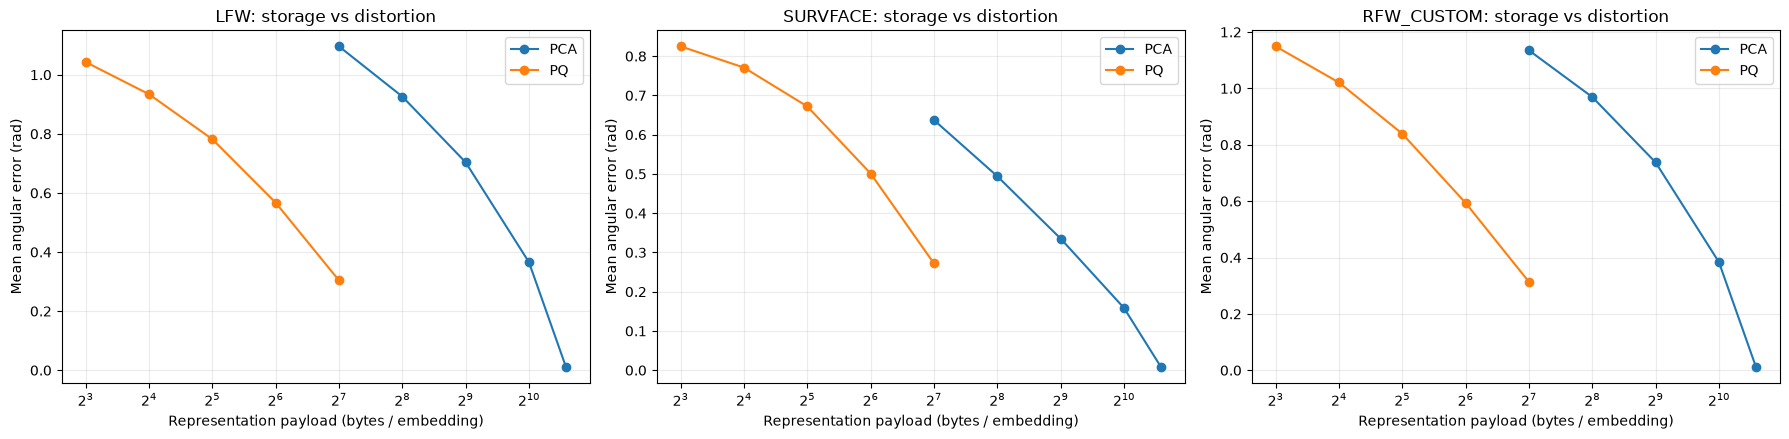

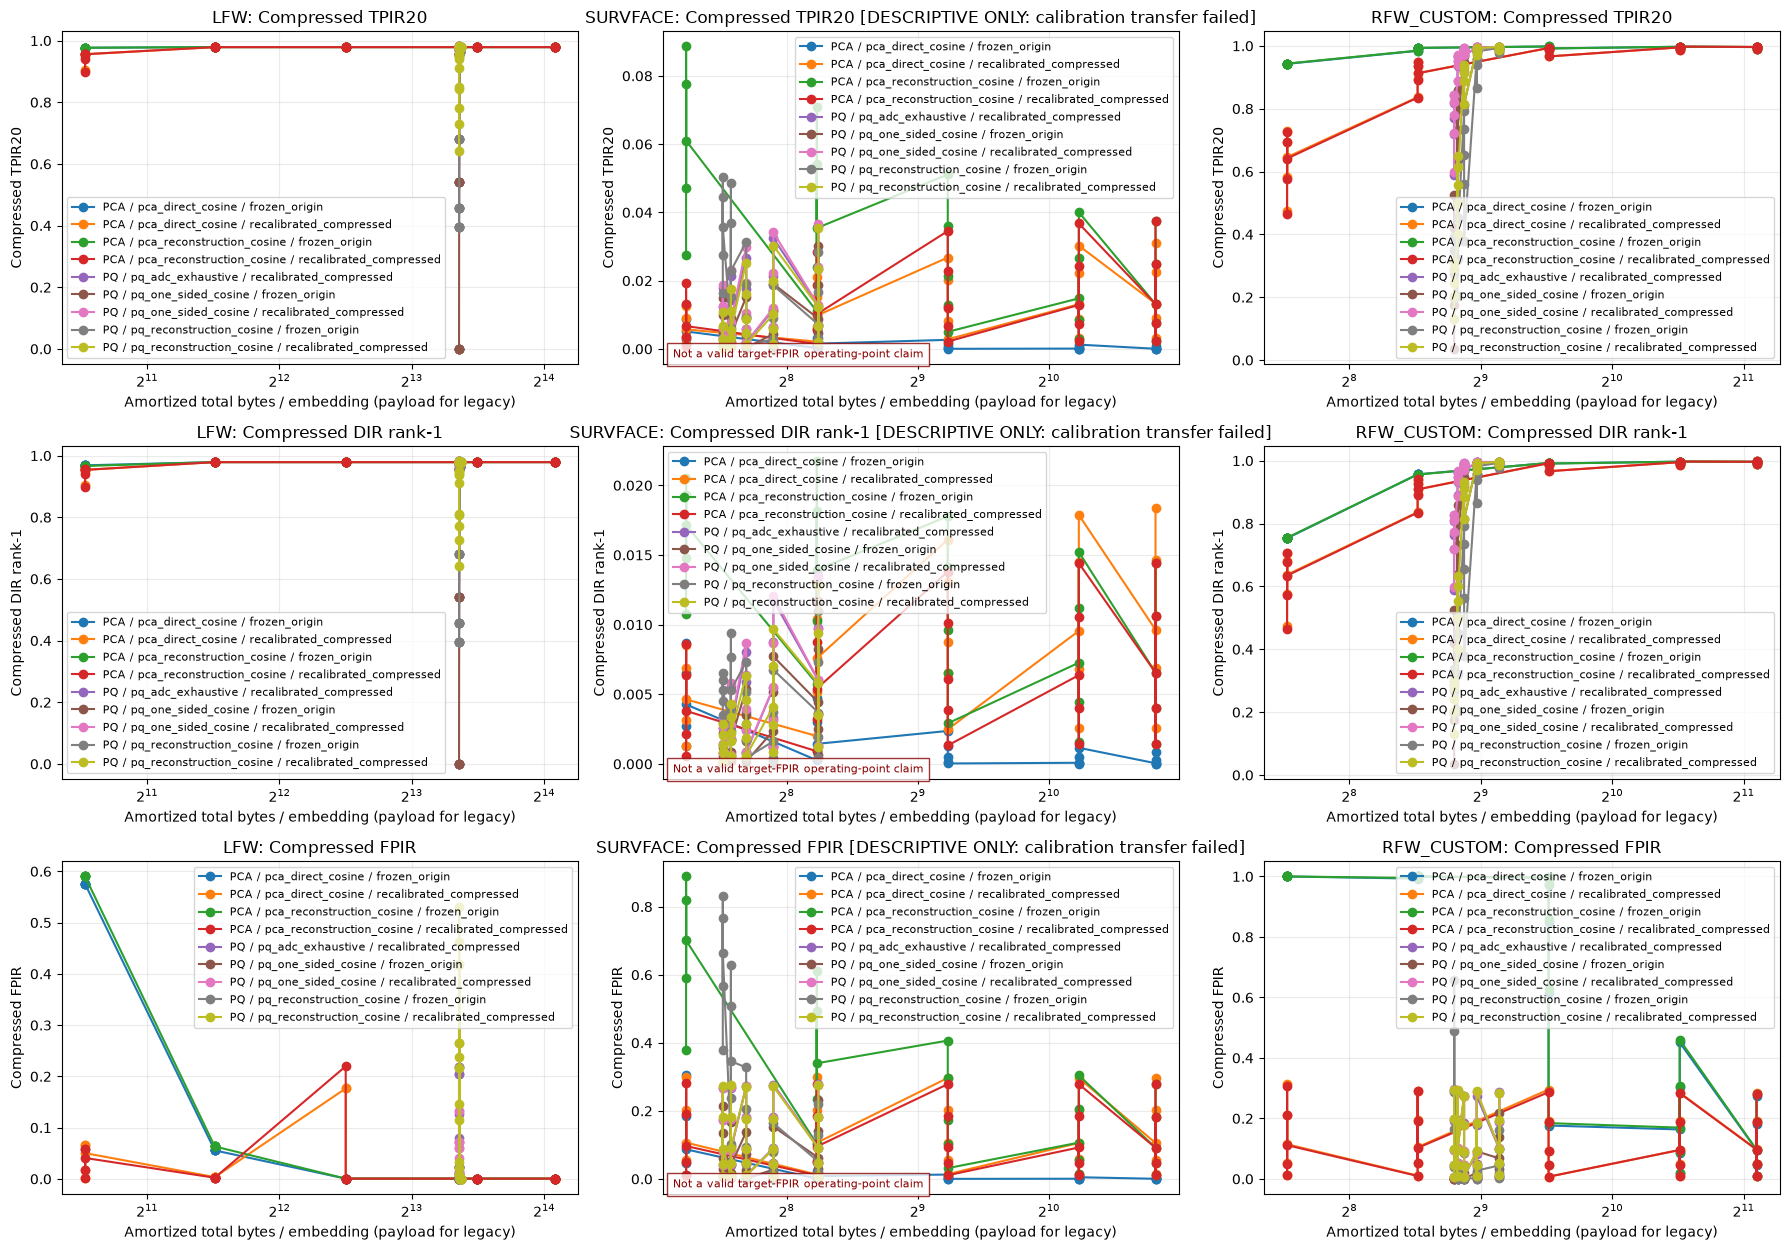

In [7]:
import matplotlib.pyplot as plt

figures = {}
dataset_order = list(DATASETS)

fig_distortion, axes = plt.subplots(
    1, len(dataset_order), figsize=(6 * len(dataset_order), 4.5), squeeze=False
)
geometry = compression_summary_all.drop_duplicates(
    ["dataset", "compression_family", "compression_profile"]
)
for axis, dataset in zip(axes[0], dataset_order):
    subset = geometry.loc[geometry["dataset"].eq(dataset)]
    for family, group in subset.groupby("compression_family", sort=True):
        ordered = group.sort_values("storage_bytes_per_embedding")
        axis.plot(
            ordered["storage_bytes_per_embedding"],
            ordered["mean_angular_error_rad"],
            marker="o",
            label=family.upper(),
        )
    axis.set_xscale("log", base=2)
    axis.set(
        title=f"{dataset.upper()}: storage vs distortion",
        xlabel="Representation payload (bytes / embedding)",
        ylabel="Mean angular error (rad)",
    )
    axis.grid(alpha=0.25)
    axis.legend()
fig_distortion.tight_layout()
figures["storage_distortion"] = fig_distortion

metrics = (
    ("compressed_tpir20", "Compressed TPIR20"),
    ("compressed_dir_rank1", "Compressed DIR rank-1"),
    ("compressed_fpir", "Compressed FPIR"),
)
fig_open_set, axes = plt.subplots(
    len(metrics), len(dataset_order),
    figsize=(6 * len(dataset_order), 4.2 * len(metrics)),
    squeeze=False,
)
for column_index, dataset in enumerate(dataset_order):
    subset = compression_summary_all.loc[
        compression_summary_all["dataset"].eq(dataset)
    ]
    for row_index, (metric, ylabel) in enumerate(metrics):
        axis = axes[row_index, column_index]
        for (family, search_mode, policy), group in subset.groupby(
            ["compression_family", "search_mode", "threshold_policy"], sort=True
        ):
            plot_group = group.copy()
            plot_group["plot_storage_bytes"] = pd.to_numeric(
                plot_group["amortized_storage_bytes_per_gallery_template"],
                errors="coerce",
            ).fillna(plot_group["storage_bytes_per_embedding"])
            ordered = plot_group.sort_values("plot_storage_bytes")
            axis.plot(
                ordered["plot_storage_bytes"],
                ordered[metric],
                marker="o",
                label=f"{family.upper()} / {search_mode} / {policy}",
            )
        axis.set_xscale("log", base=2)
        threshold_claim_blocked = bool(
            dataset == "survface"
            and SURVFACE_CALIBRATION_TRANSFER_FAILED is True
        )
        title_suffix = (
            " [DESCRIPTIVE ONLY: calibration transfer failed]"
            if threshold_claim_blocked
            else ""
        )
        axis.set(
            title=f"{dataset.upper()}: {ylabel}{title_suffix}",
            xlabel="Amortized total bytes / embedding (payload for legacy)",
            ylabel=ylabel,
        )
        if threshold_claim_blocked:
            axis.text(
                0.02, 0.02,
                "Not a valid target-FPIR operating-point claim",
                transform=axis.transAxes, color="darkred", fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "darkred"},
            )
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
fig_open_set.tight_layout()
figures["storage_open_set"] = fig_open_set

integrated_columns = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "compression_family",
    "compression_profile", "search_mode",
    "query_representation", "gallery_representation", "distance_function",
    "threshold_policy",
    "target_fpir",
    "compressed_score_space", "compressed_dir_rank1", "compressed_fpir",
    "origin_decision_threshold", "compressed_decision_threshold",
    "origin_tpir20", "compressed_tpir20",
    "compressed_tpir20_retention",
    "origin_closed_set_rank20_recall",
    "compressed_closed_set_rank20_recall",
    "origin_false_accept_count", "origin_fpir_denominator", "origin_realized_fpir",
    "compressed_false_accept_count", "compressed_fpir_denominator",
    "compressed_realized_fpir", "origin_fpir_wilson95_low",
    "origin_fpir_wilson95_high", "compressed_fpir_wilson95_low",
    "compressed_fpir_wilson95_high", "origin_dir_rank1_wilson95_low",
    "origin_dir_rank1_wilson95_high", "compressed_dir_rank1_wilson95_low",
    "compressed_dir_rank1_wilson95_high", "compressed_minus_origin_fpir",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
    "storage_bytes_per_embedding", "codebook_bytes",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
    "accept_to_reject_count", "accept_to_reject_rate",
    "reject_to_accept_count", "reject_to_accept_rate",
]
dir_fpir_storage_latency = compression_summary_all[integrated_columns].copy()
display(dir_fpir_storage_latency)


## 6. RFW-Official supplementary 1:1 verification

RFW-Official은 pair/fold 기반 TAR/FAR/Accuracy/EER artifact입니다. RFW-Custom 1:N open-set 행과 결합하지 않습니다. 같은 물리 RFW population에서 fitted/calibrated한 결과는 same-domain diagnostic이며 strict external-transfer 또는 strict unseen-identity 근거가 아닙니다.


In [8]:
from research.experiments import load_rfw_frozen_codec_evaluation

RFW_EVALUATION = None
RFW_PROFILE_SUMMARY = pd.DataFrame()
RFW_GROUP_SUMMARY = pd.DataFrame()
if RFW_EVALUATION_DIR is not None:
    rfw_dir = Path(RFW_EVALUATION_DIR)
    if not rfw_dir.is_absolute():
        rfw_dir = PROJECT_ROOT / rfw_dir
    RFW_EVALUATION = load_rfw_frozen_codec_evaluation(rfw_dir)
    rfw_manifest = RFW_EVALUATION.manifest
    if rfw_manifest.get("open_set_protocol") is not False:
        raise ValueError("RFW result must remain a 1:1 verification artifact")
    if rfw_manifest.get("codec_fit_on_rfw") is not False:
        raise ValueError("RFW result contains a codec fitted on RFW")
    if str(rfw_manifest.get("model_uid")) not in set(MODEL_UIDS.values()):
        raise ValueError("RFW model UID differs from selected open-set runs")
    RFW_PROFILE_SUMMARY = RFW_EVALUATION.profile_summary.copy()
    RFW_GROUP_SUMMARY = RFW_EVALUATION.group_summary.copy()
    required_rfw_profile_columns = {
        "macro_group_accuracy", "macro_group_eer", "group_accuracy_gap",
        "group_eer_gap", "eer_threshold_policy", "eer_threshold_source",
    }
    missing_rfw_profile = sorted(
        required_rfw_profile_columns - set(RFW_PROFILE_SUMMARY.columns)
    )
    if missing_rfw_profile:
        raise ValueError(f"RFW Official profile EER fields are missing: {missing_rfw_profile}")
    required_rfw_group_columns = {
        "mean_tar", "mean_far", "mean_eer", "eer_ci95_low", "eer_ci95_high",
    }
    missing_rfw_group = sorted(
        required_rfw_group_columns - set(RFW_GROUP_SUMMARY.columns)
    )
    if missing_rfw_group:
        raise ValueError(f"RFW Official group TAR/FAR/EER fields are missing: {missing_rfw_group}")
    if not RFW_PROFILE_SUMMARY["open_set_protocol"].eq(False).all():
        raise ValueError("RFW profile summary escaped the 1:1 protocol boundary")
display(RFW_PROFILE_SUMMARY)
display(RFW_GROUP_SUMMARY)


""


""


## 7. TinyFace official supplementary closed-set 1:N identification

TinyFace는 `Gallery_Match + Gallery_Distractor` 전체에 대해 Probe를 검색하는 공식 프로토콜입니다. mAP와 Rank-1/5/10/20만 보고하며 non-mated probe가 없으므로 FPIR/TPIR 및 threshold calibration 행은 생성하지 않습니다.

In [9]:
from research.evaluation import load_tinyface_completed_evaluation

TINYFACE_EVALUATION = None
TINYFACE_CONDITION_SUMMARY = pd.DataFrame()
TINYFACE_PER_QUERY = pd.DataFrame()
if TINYFACE_EVALUATION_DIR is not None:
    tinyface_dir = Path(TINYFACE_EVALUATION_DIR)
    if not tinyface_dir.is_absolute():
        tinyface_dir = PROJECT_ROOT / tinyface_dir
    TINYFACE_EVALUATION = load_tinyface_completed_evaluation(tinyface_dir)
    tinyface_manifest = TINYFACE_EVALUATION.manifest
    if tinyface_manifest.get("open_set_protocol") is not False:
        raise ValueError("TinyFace official result must remain closed-set")
    if tinyface_manifest.get("fpir_tpir_metrics_applicable") is not False:
        raise ValueError("TinyFace official result must not claim FPIR/TPIR applicability")
    if str(tinyface_manifest.get("model_uid")) not in set(MODEL_UIDS.values()):
        raise ValueError("TinyFace model UID differs from selected open-set runs")
    TINYFACE_CONDITION_SUMMARY = TINYFACE_EVALUATION.condition_summary.copy()
    TINYFACE_PER_QUERY = TINYFACE_EVALUATION.per_query.copy()
    required_tinyface_columns = {
        "mean_average_precision", "rank_1", "rank_5", "rank_10", "rank_20",
        "rank_20_wilson95_low", "rank_20_wilson95_high",
        "gallery_storage_bytes_per_vector_amortized",
        "query_representation", "gallery_representation", "distance_function",
        "fpir_tpir_metrics_applicable",
    }
    missing_tinyface = sorted(
        required_tinyface_columns - set(TINYFACE_CONDITION_SUMMARY.columns)
    )
    if missing_tinyface:
        raise ValueError(f"TinyFace summary fields are missing: {missing_tinyface}")
    if not TINYFACE_CONDITION_SUMMARY["fpir_tpir_metrics_applicable"].eq(False).all():
        raise ValueError("TinyFace summary escaped the closed-set metric boundary")
    forbidden_open_set_columns = {
        "target_fpir", "realized_fpir", "tpir20", "threshold_policy",
    }
    if forbidden_open_set_columns & set(TINYFACE_CONDITION_SUMMARY.columns):
        raise ValueError("TinyFace summary contains forbidden open-set columns")
    tinyface_sdc_profiles = set(
        TINYFACE_CONDITION_SUMMARY.loc[
            TINYFACE_CONDITION_SUMMARY["search_mode"].eq("pq_sdc_exhaustive"),
            "compression_profile",
        ].astype(str)
    )
    if tinyface_sdc_profiles != set(EXPECTED_PQ_SDC_PROFILES):
        raise ValueError(
            "TinyFace SDC profile contract mismatch: "
            f"{sorted(tinyface_sdc_profiles)}"
        )

display_columns = [
    "compression_family", "compression_profile", "search_mode",
    "query_representation", "gallery_representation", "distance_function",
    "mean_average_precision", "rank_1", "rank_5", "rank_10", "rank_20",
    "rank_20_wilson95_low", "rank_20_wilson95_high",
    "gallery_storage_bytes_per_vector_amortized", "paper_eligible",
]
display(
    TINYFACE_CONDITION_SUMMARY[display_columns]
    if not TINYFACE_CONDITION_SUMMARY.empty
    else TINYFACE_CONDITION_SUMMARY
)


,compression_family,compression_profile,search_mode,query_representation,gallery_representation,distance_function,mean_average_precision,rank_1,rank_5,rank_10,rank_20,rank_20_wilson95_low,rank_20_wilson95_high,gallery_storage_bytes_per_vector_amortized,paper_eligible
0,origin,origin_512,origin_cosine,origin_float32,origin_float32,cosine_similarity,0.171228,0.236320,0.289163,0.311695,0.337983,0.322972,0.353327,2048.000000,True
1,pca,pca_384,pca_direct_cosine,pca_384_float32,pca_384_float32,cosine_similarity,0.178720,0.247049,0.304721,0.328863,0.353004,0.337822,0.368489,1540.994457,True
2,pca,pca_384,pca_reconstruction_cosine,pca_384_reconstruction_512,pca_384_reconstruction_512,cosine_similarity,0.171231,0.236588,0.289163,0.311695,0.337983,0.322972,0.353327,1540.994457,True
3,pca,pca_256,pca_direct_cosine,pca_256_float32,pca_256_float32,cosine_similarity,0.178185,0.246513,0.300966,0.326717,0.352200,0.337026,0.367678,1027.333963,True
4,pca,pca_256,pca_reconstruction_cosine,pca_256_reconstruction_512,pca_256_reconstruction_512,cosine_similarity,0.169023,0.233101,0.286212,0.310086,0.336373,0.321382,0.351701,1027.333963,True
5,pca,pca_128,pca_direct_cosine,pca_128_float32,pca_128_float32,cosine_similarity,0.168687,0.235783,0.290236,0.310891,0.340129,0.325093,0.355494,513.673468,True
6,pca,pca_128,pca_reconstruction_cosine,pca_128_reconstruction_512,pca_128_reconstruction_512,cosine_similarity,0.161056,0.224517,0.275751,0.301234,0.322425,0.307610,0.337605,513.673468,True
7,pca,pca_64,pca_direct_cosine,pca_64_float32,pca_64_float32,cosine_similarity,0.143028,0.199034,0.260461,0.282725,0.305794,0.291210,0.320778,256.843220,True
8,pca,pca_64,pca_reconstruction_cosine,pca_64_reconstruction_512,pca_64_reconstruction_512,cosine_similarity,0.139524,0.192328,0.250536,0.271191,0.295869,0.281434,0.310725,256.843220,True
9,pca,pca_32,pca_direct_cosine,pca_32_float32,pca_32_float32,cosine_similarity,0.107375,0.146996,0.203863,0.227736,0.255901,0.242150,0.270155,128.428096,True


## 8. Dataset-level Grad-CAM faithfulness (configurable cap; None = all eligible candidates)

모델별 checkpoint와 동일한 source run을 검증한 high/low/random occlusion artifact만 포함합니다. 모델 family의 인과효과가 아니라 checkpoint-level 결과입니다.

In [10]:
from research.evaluation import load_selected_faithfulness_artifacts

FAITHFULNESS_SUMMARY_ALL = pd.DataFrame()
FAITHFULNESS_MANIFESTS = {}
FAITHFULNESS_ROOTS = {}
if INCLUDE_FAITHFULNESS:
    faithfulness_artifacts = load_selected_faithfulness_artifacts(
        PROJECT_ROOT,
        datasets=DATASETS,
        model_uids=MODEL_UIDS,
        run_ids=SELECTED_RUN_IDS,
        maximum_samples=FAITHFULNESS_MAXIMUM_SAMPLES,
        missing_policy="omit",
    )
    FAITHFULNESS_SUMMARY_ALL = faithfulness_artifacts.summary
    FAITHFULNESS_MANIFESTS = faithfulness_artifacts.manifests
    FAITHFULNESS_ROOTS = faithfulness_artifacts.roots
    if faithfulness_artifacts.missing_manifests:
        missing_faithfulness = pd.DataFrame.from_records([
            {
                "dataset": dataset,
                "status": "omitted_missing_optional_manifest",
                "expected_manifest": path.relative_to(PROJECT_ROOT).as_posix(),
            }
            for dataset, path in faithfulness_artifacts.missing_manifests.items()
        ])
        print(
            "WARNING: 선택 run에 없는 optional faithfulness artifact는 "
            "공통 보고서에서만 생략합니다. TPIR20/압축/검색 결과는 유지됩니다."
        )
        display(missing_faithfulness)
display(FAITHFULNESS_SUMMARY_ALL)


,dataset,model_uid,source_run_id,evaluation_mode,group,metric,sample_count,identity_count,mean,median,positive_fraction,mean_ci_lower,mean_ci_upper,confidence_level,bootstrap_method,bootstrap_repeats
0,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,inline_full,all,high_saliency_occlusion_score_drop,9133,1674,0.050025,0.038390,0.954013,0.047634,0.052305,0.95,identity_cluster,1000
1,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,inline_full,all,low_saliency_occlusion_score_drop,9133,1674,0.055249,0.051298,0.962991,0.053769,0.057026,0.95,identity_cluster,1000
2,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,inline_full,all,random_occlusion_score_drop,9133,1674,0.058287,0.054601,0.987737,0.057204,0.059378,0.95,identity_cluster,1000
3,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,inline_full,all,faithfulness_gain_over_low_saliency,9133,1674,-0.005224,-0.010593,0.426366,-0.008876,-0.001457,0.95,identity_cluster,1000
4,lfw,adaface-4df25b75e065b0b9ed43,20260830-R001-2c810919,inline_full,all,faithfulness_gain_over_random,9133,1674,-0.008262,-0.013708,0.374795,-0.011118,-0.005491,0.95,identity_cluster,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,rfw_custom,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,derived_stratified,rfw_group=Indian,high_saliency_occlusion_score_drop,2499,1617,0.052107,0.041542,0.934374,0.050309,0.053943,0.95,identity_cluster,1000
86,rfw_custom,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,derived_stratified,rfw_group=Indian,low_saliency_occlusion_score_drop,2499,1617,0.053070,0.046857,0.930772,0.051285,0.054942,0.95,identity_cluster,1000
87,rfw_custom,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,derived_stratified,rfw_group=Indian,random_occlusion_score_drop,2499,1617,0.063432,0.056878,0.979592,0.061698,0.065170,0.95,identity_cluster,1000
88,rfw_custom,adaface-4df25b75e065b0b9ed43,20260830-R001-9f3f1375,derived_stratified,rfw_group=Indian,faithfulness_gain_over_low_saliency,2499,1617,-0.000964,-0.004318,0.472589,-0.003783,0.001730,0.95,identity_cluster,1000


## 9. 공통 CSV·그림·manifest 저장

compact table, LFW·SurvFace TPIR20–FPIR appendix, Origin/query-gallery/score-space calibration 비교표, 그림과 lineage manifest만 기록합니다. 대용량 query/sample ledger는 복제하지 않습니다.


In [11]:
from datetime import datetime, timezone

selection_tag = "__".join(
    f"{dataset}-{SELECTED_RUN_IDS[dataset]}" for dataset in DATASETS
)
if TINYFACE_EVALUATION is not None:
    selection_tag += f"__tinyface-{TINYFACE_EVALUATION.manifest['source_run_id']}"
COMMON_OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "paper" / "common" / MODEL_NAME / selection_tag
)
export_result = {
    "status": "computed_not_written",
    "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "compression_summary_all_rows": int(len(compression_summary_all)),
    "saliency_geometry_association_rows": int(len(SALIENCY_GEOMETRY_ALL)),
    "saliency_retrieval_association_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
    "threshold_instability_association_rows": int(len(THRESHOLD_INSTABILITY_ALL)),
    "threshold_policy_comparison_rows": int(len(THRESHOLD_POLICY_COMPARISON_ALL)),
    "threshold_policy_saliency_rho_rows": int(len(THRESHOLD_POLICY_SALIENCY_RHO_ALL)),
    "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
    "faithfulness_summary_rows": int(len(FAITHFULNESS_SUMMARY_ALL)),
    "faithfulness_dataset_count": int(len(FAITHFULNESS_MANIFESTS)),
    "faithfulness_maximum_samples_per_dataset": FAITHFULNESS_MAXIMUM_SAMPLES,
    "tinyface_condition_rows": int(len(TINYFACE_CONDITION_SUMMARY)),
}

if WRITE_OUTPUTS:
    COMMON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_paths = {
        "compression_summary_all.csv": COMMON_OUTPUT_DIR / "compression_summary_all.csv",
        "retrieval_summary_all.csv": COMMON_OUTPUT_DIR / "retrieval_summary_all.csv",
        "saliency_geometry_associations_all.csv": COMMON_OUTPUT_DIR / "saliency_geometry_associations_all.csv",
        "saliency_retrieval_associations_all.csv": COMMON_OUTPUT_DIR / "saliency_retrieval_associations_all.csv",
        "saliency_threshold_instability_associations_all.csv": COMMON_OUTPUT_DIR / "saliency_threshold_instability_associations_all.csv",
        "saliency_threshold_policy_comparisons_all.csv": COMMON_OUTPUT_DIR / "saliency_threshold_policy_comparisons_all.csv",
        "saliency_threshold_policy_rho_comparisons_all.csv": COMMON_OUTPUT_DIR / "saliency_threshold_policy_rho_comparisons_all.csv",
        "representative_cases_all.csv": COMMON_OUTPUT_DIR / "representative_cases_all.csv",
        "dir_fpir_storage_latency.csv": COMMON_OUTPUT_DIR / "dir_fpir_storage_latency.csv",
        "lfw_survface_fpir_appendix.csv": COMMON_OUTPUT_DIR / "lfw_survface_fpir_appendix.csv",
        "tpir20_method_comparison.csv": COMMON_OUTPUT_DIR / "tpir20_method_comparison.csv",
        "pq_query_gallery_operating_points.csv": COMMON_OUTPUT_DIR / "pq_query_gallery_operating_points.csv",
        "survface_tpir20_comparison.csv": COMMON_OUTPUT_DIR / "survface_tpir20_comparison.csv",
        "storage_distortion.png": COMMON_OUTPUT_DIR / "storage_distortion.png",
        "storage_open_set.png": COMMON_OUTPUT_DIR / "storage_open_set.png",
    }
    if not FAITHFULNESS_SUMMARY_ALL.empty:
        output_paths["faithfulness_summary_all.csv"] = (
            COMMON_OUTPUT_DIR / "faithfulness_summary_all.csv"
        )
    if not TINYFACE_CONDITION_SUMMARY.empty:
        output_paths["tinyface_official_compression_summary.csv"] = (
            COMMON_OUTPUT_DIR / "tinyface_official_compression_summary.csv"
        )
        output_paths["tinyface_official_per_query.csv"] = (
            COMMON_OUTPUT_DIR / "tinyface_official_per_query.csv"
        )
    if not RFW_PROFILE_SUMMARY.empty:
        output_paths["rfw_profile_summary.csv"] = (
            COMMON_OUTPUT_DIR / "rfw_profile_summary.csv"
        )
        output_paths["rfw_group_summary.csv"] = (
            COMMON_OUTPUT_DIR / "rfw_group_summary.csv"
        )
    existing = [path for path in output_paths.values() if path.exists()]
    manifest_path = COMMON_OUTPUT_DIR / "cross_dataset_summary_manifest.json"
    if manifest_path.exists():
        existing.append(manifest_path)
    if existing and not OVERWRITE_COMMON_OUTPUTS:
        raise FileExistsError(
            f"공통 출력이 이미 있습니다. OVERWRITE_COMMON_OUTPUTS=True가 필요합니다: {existing}"
        )

    compression_summary_all.to_csv(
        output_paths["compression_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    retrieval_summary_all.to_csv(
        output_paths["retrieval_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    SALIENCY_GEOMETRY_ALL.to_csv(
        output_paths["saliency_geometry_associations_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    SALIENCY_RETRIEVAL_ALL.to_csv(
        output_paths["saliency_retrieval_associations_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    THRESHOLD_INSTABILITY_ALL.to_csv(
        output_paths["saliency_threshold_instability_associations_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    THRESHOLD_POLICY_COMPARISON_ALL.to_csv(
        output_paths["saliency_threshold_policy_comparisons_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    THRESHOLD_POLICY_SALIENCY_RHO_ALL.to_csv(
        output_paths["saliency_threshold_policy_rho_comparisons_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    REPRESENTATIVE_CASES_ALL.to_csv(
        output_paths["representative_cases_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    dir_fpir_storage_latency.to_csv(
        output_paths["dir_fpir_storage_latency.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    lfw_survface_fpir_appendix.to_csv(
        output_paths["lfw_survface_fpir_appendix.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    tpir20_method_comparison.to_csv(
        output_paths["tpir20_method_comparison.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )

    pq_query_gallery_operating_points.to_csv(
        output_paths["pq_query_gallery_operating_points.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    survface_tpir20_comparison.to_csv(
        output_paths["survface_tpir20_comparison.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    if not FAITHFULNESS_SUMMARY_ALL.empty:
        FAITHFULNESS_SUMMARY_ALL.to_csv(
            output_paths["faithfulness_summary_all.csv"],
            index=False,
            encoding="utf-8",
            lineterminator="\n",
            float_format="%.12g",
        )
    if not TINYFACE_CONDITION_SUMMARY.empty:
        TINYFACE_CONDITION_SUMMARY.to_csv(
            output_paths["tinyface_official_compression_summary.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
        TINYFACE_PER_QUERY.to_csv(
            output_paths["tinyface_official_per_query.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
    if not RFW_PROFILE_SUMMARY.empty:
        RFW_PROFILE_SUMMARY.to_csv(
            output_paths["rfw_profile_summary.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
        RFW_GROUP_SUMMARY.to_csv(
            output_paths["rfw_group_summary.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
    figures["storage_distortion"].savefig(
        output_paths["storage_distortion.png"], dpi=180, bbox_inches="tight"
    )
    figures["storage_open_set"].savefig(
        output_paths["storage_open_set.png"], dpi=180, bbox_inches="tight"
    )

    common_manifest = {
        "schema_version": 11,
        "artifact_type": "cross_dataset_results",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "model_name": MODEL_NAME,
        "datasets": list(DATASETS),
        "comparison_unit": "pretrained_checkpoint",
        "causal_loss_claim": False,
        "confidence_interval_contract": {
            "unit": "probe",
            "rates": "two-sided Wilson score 95%",
            "compressed_minus_origin": (
                "paired nonparametric bootstrap percentile 95%; 2000 repeats; seed 42"
            ),
            "does_not_cover": ["identity_cluster", "checkpoint_training_uncertainty"],
        },
        "tpir20_contract": {
            "rank": 20,
            "target_fpirs": list(TARGET_FPIRS),
            "threshold_source": "calibration",
            "thresholded_score": "true_identity_score_within_top20",
            "retention": "compressed_tpir20 / origin_tpir20",

            "method_rows": [
                "origin", "compressed_frozen_threshold",
                "compressed_recalibrated",
            ],
            "reported_fields": [
                "realized_fpir", "tpir20", "closed_set_rank20_recall",
                "wilson95_ci", "paired_delta_ci", "storage",
            ],
        },

        "query_gallery_condition_contract": {
            "pq_search_modes": list(SELECTED_PQ_SEARCH_MODES),
            "origin": {
                "query": "origin_float32",
                "gallery": "origin_float32",
                "distance": "cosine_similarity",
            },
            "score_space_specific_calibration": True,
            "frozen_origin_allowed_modes": [
                mode for mode in SELECTED_PQ_SEARCH_MODES
                if search_condition(mode).frozen_origin_threshold_applicable
            ],
            "sdc_role": "supplementary_deployment_point_ablation",
            "pq_sdc_settings": [list(value) for value in EXPECTED_PQ_SDC_SETTINGS],
            "pq_sdc_profiles": list(EXPECTED_PQ_SDC_PROFILES),
        },
        "tinyface_official": (
            {
                "included": True,
                "evaluation_role": "supplementary_closed_set_1toN_identification",
                "open_set_protocol": False,
                "non_mated_probe_count": 0,
                "fpir_tpir_metrics_applicable": False,
                "model_uid": TINYFACE_EVALUATION.manifest["model_uid"],
                "source_run_id": TINYFACE_EVALUATION.manifest["source_run_id"],
                "protocol_uid": TINYFACE_EVALUATION.manifest["protocol_uid"],
                "official_result_eligible": TINYFACE_EVALUATION.manifest[
                    "official_result_eligible"
                ],
                "metrics": ["mean_average_precision", "rank_1", "rank_5", "rank_10", "rank_20"],
                "source_manifest": {
                    "path": str(
                        TINYFACE_EVALUATION.root
                        / "artifacts/tinyface_official/tinyface_evaluation_manifest.json"
                    ),
                    "sha256": sha256_file(
                        TINYFACE_EVALUATION.root
                        / "artifacts/tinyface_official/tinyface_evaluation_manifest.json"
                    ),
                },
            }
            if TINYFACE_EVALUATION is not None
            else {"included": False}
        ),
        "rfw_custom_boundary": {
            "protocol": "custom_1_to_n_open_set_identification",
            "official_result_eligible": False,
            "checkpoint_overlap_status": "UNKNOWN",
            "strict_unseen_identity_evidence": False,
        },
        "deferred_work": [
            "faiss_ivf_pq", "pgvector_ivfflat", "ann_parameter_sweep",
            "balancedface", "uncertainty_defer_high_low_risk_queries",
            "tinyface_open_set_protocol_not_defined_or_claimed",
        ],
        "survface_threshold_claim_status": (
            "blocked_calibration_transfer"
            if SURVFACE_CALIBRATION_TRANSFER_FAILED is True
            else "not_flagged"
        ),
        "selected_runs": {
            dataset: {
                "run_id": SELECTED_RUN_IDS[dataset],
                "model_uid": MODEL_UIDS[dataset],
                "run_dir": SELECTED_RUNS[dataset].relative_to(PROJECT_ROOT).as_posix(),
                "summary_artifact_type": SUMMARY_MANIFESTS[dataset]["artifact_type"],
                "summary_claim_status": SUMMARY_MANIFESTS[dataset].get(
                    "claim_status", "legacy_source_run"
                ),
                "summary_manifest": {
                    "path": (
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ).relative_to(PROJECT_ROOT).as_posix(),
                    "sha256": sha256_file(
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ),
                },
            }
            for dataset in DATASETS
        },
        "saliency_associations": {
            "included": True,
            "geometry_rows": int(len(SALIENCY_GEOMETRY_ALL)),
            "retrieval_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
            "threshold_instability_rows": int(len(THRESHOLD_INSTABILITY_ALL)),
            "threshold_policy_comparison_rows": int(len(THRESHOLD_POLICY_COMPARISON_ALL)),
            "threshold_policy_saliency_rho_rows": int(len(THRESHOLD_POLICY_SALIENCY_RHO_ALL)),
            "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
            "bootstrap_unit": "identity_id",
            "source_files": SALIENCY_ASSOCIATIONS.source_files,
        },
        "rfw_verification": (
            {
                "included": True,
                "evaluation_role": "supplementary_1to1_verification",
                "open_set_protocol": False,
                "codec_fit_on_rfw": False,
                "model_uid": RFW_EVALUATION.manifest["model_uid"],
                "codec_count": len(RFW_EVALUATION.manifest.get("codecs", [])),
                "source_manifest": {
                    "path": str(RFW_EVALUATION.root / "rfw_frozen_codec_manifest.json"),
                    "sha256": sha256_file(
                        RFW_EVALUATION.root / "rfw_frozen_codec_manifest.json"
                    ),
                },
            }
            if RFW_EVALUATION is not None
            else {"included": False}
        ),
        "faithfulness": {
            "included": bool(FAITHFULNESS_MANIFESTS),
            "maximum_samples_per_dataset": FAITHFULNESS_MAXIMUM_SAMPLES,
            "threshold_independent": True,
            "datasets": {
                dataset: {
                    "evaluation_mode": manifest["evaluation_mode"],
                    "candidate_count": manifest["sampling"]["candidate_count"],
                    "selected_count": manifest["sampling"]["selected_count"],
                    "source_manifest": {
                        "path": (FAITHFULNESS_ROOTS[dataset] / "manifest.json").relative_to(PROJECT_ROOT).as_posix(),
                        "sha256": sha256_file(FAITHFULNESS_ROOTS[dataset] / "manifest.json"),
                    },
                }
                for dataset, manifest in FAITHFULNESS_MANIFESTS.items()
            },
        },
        "cross_model_open_set_matrix": (
            {
                "included": True,
                "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
                "complete_matrix": True,
                "model_families": CROSS_MODEL_SELECTION_MANIFEST[
                    "model_families"
                ],
                "open_set_datasets": CROSS_MODEL_SELECTION_MANIFEST[
                    "open_set_datasets"
                ],
                "interpretation": "checkpoint_level_generalization",
            }
            if CROSS_MODEL_SELECTION_MANIFEST is not None
            else {"included": False}
        ),
        "join_contract": {
            "grain": (
                "one row per dataset, model, run, compression profile, "
                "search mode, threshold policy, and target FPIR"
            ),
            "validation": "compression one-to-retrieval many",
            "rows": int(len(compression_summary_all)),
        },
        "output_files": {
            name: {
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for name, path in output_paths.items()
        },
    }
    manifest_path.write_text(
        json.dumps(common_manifest, ensure_ascii=False, indent=2, sort_keys=True)
        + "\n",
        encoding="utf-8",
        newline="\n",
    )
    export_result = {
        "status": "written",
        "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
        "manifest": manifest_path.relative_to(PROJECT_ROOT).as_posix(),
        "compression_summary_all_rows": int(len(compression_summary_all)),
        "retrieval_summary_all_rows": int(len(retrieval_summary_all)),
        "saliency_geometry_association_rows": int(len(SALIENCY_GEOMETRY_ALL)),
        "saliency_retrieval_association_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
        "threshold_instability_association_rows": int(len(THRESHOLD_INSTABILITY_ALL)),
        "threshold_policy_comparison_rows": int(len(THRESHOLD_POLICY_COMPARISON_ALL)),
        "threshold_policy_saliency_rho_rows": int(len(THRESHOLD_POLICY_SALIENCY_RHO_ALL)),
        "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
        "tinyface_condition_rows": int(len(TINYFACE_CONDITION_SUMMARY)),
    }
if CROSS_MODEL_MATRIX is None:
    export_result["cross_model_matrix"] = {"status": "not_configured"}
elif WRITE_OUTPUTS:
    matrix_write = write_cross_model_open_set_matrix(
        CROSS_MODEL_MATRIX,
        PROJECT_ROOT / "results/paper/common/four_model_three_dataset",
        overwrite=OVERWRITE_COMMON_OUTPUTS,
    )
    export_result["cross_model_matrix"] = {
        "status": "written",
        "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
        "destination": matrix_write.output_dir.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "manifest": matrix_write.manifest_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
    }
else:
    export_result["cross_model_matrix"] = {
        "status": "validated_not_written",
        "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
        "joined_rows": int(len(CROSS_MODEL_JOINED)),
    }
export_result


{'status': 'written',
 'destination': 'results/paper/common/adaface/lfw-20260830-R001-2c810919__survface-20260830-R001-ec6e5d4a__rfw_custom-20260830-R001-9f3f1375__tinyface-20260830-R001-8de2477d',
 'manifest': 'results/paper/common/adaface/lfw-20260830-R001-2c810919__survface-20260830-R001-ec6e5d4a__rfw_custom-20260830-R001-9f3f1375__tinyface-20260830-R001-8de2477d/cross_dataset_summary_manifest.json',
 'compression_summary_all_rows': 675,
 'retrieval_summary_all_rows': 675,
 'saliency_geometry_association_rows': 1710,
 'saliency_retrieval_association_rows': 410400,
 'threshold_instability_association_rows': 60750,
 'threshold_policy_comparison_rows': 1800,
 'threshold_policy_saliency_rho_rows': 3600,
 'representative_case_rows': 9130,
 'tinyface_condition_rows': 26,
 'cross_model_matrix': {'status': 'not_configured'}}

## Final check

- 세 open-set dataset은 protocol UID와 population이 다르며 절대 DIR/FPIR 난이도를 동일시하지 않습니다.
- 모든 compact 행은 TPIR20@FPIR 1%/5%/10%/20%/30%, threshold, false accept 수·분모·realized FPIR, retention, Wilson CI와 paired delta CI를 보존합니다.
- source ledger의 `origin_fallback_used`는 compact `origin_fallback_count=0`으로 재검증합니다.
- `frozen_origin`과 `recalibrated_compressed`를 분리하고 PCA direct/reconstruction 및 PQ reconstruction/ADC를 합치지 않습니다.
- CI는 probe-level이며 checkpoint 재학습 불확실성이 아닙니다.
- ArcFace·AdaFace·MagFace·EdgeFace 결과는 checkpoint-level 비교입니다.
- 4×3 통합 표는 `MODEL_RUN_MATRIX`에 명시된 12개 완료 run이 모두 검증된 경우에만 생성합니다.
- EdgeFace–RFW overlap은 `UNKNOWN`; RFW는 strict unseen-identity evidence가 아닙니다.
- RFW-Custom 1:N과 RFW-Official 1:1 TAR/FAR/EER는 별도 artifact와 표로 유지합니다.
- IVF-PQ, pgvector IVFFlat, ANN sweep, BalancedFace, uncertainty/defer는 유예 상태입니다.


- PQ 주 비교는 `pq_reconstruction_cosine`, `pq_one_sided_cosine`, `pq_adc_exhaustive`이며 `pq_sdc_exhaustive`는 보조 ablation입니다.
- ADC/SDC는 cosine과 score-space가 다르므로 `recalibrated_compressed`만 유효합니다.
- `target_met_on_test=False` 행은 목표 FPIR operating-point 성능으로 인용하지 않습니다.
- TinyFace는 별도 open-set custom protocol이 고정되기 전까지 이 표에 포함하지 않습니다.
